<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_02_target_definition/stage_02a_target_investigation_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **stage_02a_target_investigation**


## **Introducción**

En problemas de *Machine Learning aplicado a trading*, la definición del **target** no es un paso trivial ni secundario, sino una de las decisiones más críticas de todo el pipeline.

De acuerdo con el enfoque presentado en *Machine Learning for Algorithmic Trading*, el proceso comienza no por el modelo, sino por la correcta formulación del problema:

> “Frame the problem, identify a target metric, and define success.”

Esto implica que:

- El **target define el tipo de problema** (regresión, clasificación, ranking)  
- Condiciona completamente:
  - las features
  - el modelo
  - las métricas de evaluación  
- Determina, en última instancia, si el modelo tendrá valor económico  

---

**2. El target en trading no es único**

A diferencia de otros dominios, en trading no existe una única definición correcta de target. El mismo problema puede formularse de distintas maneras:

> “You could frame this task as a regression problem that aims to predict returns, a binary classification problem that aims to predict the direction…”

Esto da lugar a múltiples enfoques posibles:

- **Regresión** → predecir retornos futuros  
- **Clasificación** → predecir dirección (sube / baja)  
- **Ranking** → ordenar oportunidades (percentiles, quintiles)  

En este contexto, distintas definiciones como:

- `delta_60`  
- `ret_60`  
- dirección del movimiento  

representan distintas formas válidas de formular el mismo problema.

---

**3. Target estándar: forward returns**

En la práctica, el enfoque más común consiste en utilizar **retornos futuros desplazados en el tiempo** como variable objetivo:

> “We shift returns… so that this value becomes the model target”  

Conceptualmente:

```python
target_t = return(t → t + horizon)
```

Esto valida directamente el uso de targets como:

- `ret_60`  
- `delta_60`  

ambos derivados de información futura respecto al instante actual.

---

**4. Alineación con el objetivo económico**

El objetivo fundamental en trading es la generación de alpha, lo cual está directamente ligado a la predicción de retornos:

> “The goal… is to predict future returns”

> “The key to generating alpha is having accurate return forecasts”

Por lo tanto:

- El target debe estar **alineado con el PnL**  
- No debe ser arbitrario  
- Debe representar una magnitud económicamente explotable  

---

**5. Alternativa: predicción direccional**

El libro también introduce una consideración importante:

> “The goal… is the accurate directional prediction of future returns”

Esto implica que:

- No siempre es necesario predecir el valor exacto del retorno  
- Puede ser suficiente predecir correctamente la **dirección del movimiento**  

Este enfoque es especialmente relevante cuando:

- La magnitud es ruidosa  
- Pero existe señal en la dirección  

---

**6. Conclusión conceptual**

El libro no prescribe un único target, sino que establece principios:

1. El target debe representar **retornos futuros**  

2. Puede formularse de distintas formas:
   - magnitud (regresión)  
   - dirección (clasificación)  
   - ranking (orden relativo)  

3. La elección depende de:
   - la **existencia de señal en los datos**  
   - el **objetivo operativo del modelo**  

---

**7. Motivación para este stage**

Dado que el target no está definido a priori, su elección debe ser **validada empíricamente**.

Resultados preliminares como:

- R² ≈ 0  
- Directional Accuracy ≈ 0.50  

sugieren que:

> El problema puede no estar en el modelo, sino en la **definición del target**.

---

**8. Objetivo del STAGE_02**

El propósito de este stage es:

- Evaluar exhaustivamente distintas definiciones de target  
- Analizar su:
  - distribución  
  - estabilidad  
  - señal predictiva  
- Identificar qué formulación (si alguna) contiene señal explotable  

Este análisis constituye la base sobre la cual se construirá todo el pipeline posterior.

## **Plan de Investigación de Targets**

**Objetivo**

Definir y evaluar distintas formulaciones de target sobre el dataset `mnq_intraday`, con el fin de identificar si existe señal predictiva explotable alineada con trading.

---

**1. Definición del universo de targets**

Se construirán múltiples targets basados en el precio `close`, considerando distintos horizontes.

1.1 Targets de regresión (base del libro)

- `delta_h` → diferencia en puntos  
  Definición: close(t + h) - close(t)

- `ret_h` → retorno relativo  
  Definición: (close(t + h) / close(t)) - 1

Horizontes iniciales:

- h ∈ {15, 30, 60, 90}

---

1.2 Targets derivados (estructura de señal)

- `direction_h` → dirección del movimiento  
  Definición: sign(delta_h)

- `abs_delta_h` → magnitud del movimiento  
  Definición: abs(delta_h)

- `delta_h_clipped` → winsorizado (control de outliers)  
  Definición: clip(delta_h, lower_bound, upper_bound)

---

**2. Validación estructural del target**

Para cada target definido:

2.1 Chequeos básicos

- Valores nulos (NaN por shifting)  
- Consistencia temporal (no leakage)  
- Distribución global  

---

2.2 Análisis estadístico

- Media y desviación estándar  
- Percentiles (p5, p25, p50, p75, p95)  
- Asimetría (skewness)  
- Curtosis  

---

2.3 Análisis de ruido vs señal

- Histograma del target  
- Proporción de movimientos pequeños vs grandes  

Para dirección:

- Balance de clases (≈ 50% esperado)  

---

**3. Estabilidad temporal por régimen intradía**

Usando flags existentes:

- `is_premarket`  
- `is_opening`  
- `is_regular`  
- `is_closing`  
- `is_overnight`  

Objetivo:

- Detectar cambios de distribución según régimen  

---

**4. Dependencia temporal (predictabilidad base)**

4.1 Autocorrelación

- ACF del target  
- ACF de:
  - returns  
  - delta  

4.2 Persistencia direccional

- P(direction_t == direction_t-1)

---

**5. Relación con variables base (señal mínima)**

Sin features avanzadas, evaluar relación con:

- `close`  
- `volume`  
- `minute_of_day`  
- régimen intradía  

Métricas:

- correlación simple  
- análisis por buckets  

---

**6. Evaluación económica preliminar**

6.1 Magnitud vs ruido

- Comparar:
  - media(|delta_h|)  
  - vs costos implícitos (spread, slippage)  

6.2 Frecuencia de movimientos explotables

- % de casos donde |delta_h| > threshold  

---

**7. Criterios de selección de target**

Un target será considerado viable si cumple:

- No es ruido puro (estructura visible en distribución)  
- Tiene estabilidad razonable en el tiempo  
- Presenta alguna dependencia temporal o estructural  
- Tiene magnitud suficiente para trading  

---

**8. Output del stage**

Se generarán:

- Tablas resumen por target  
- Gráficos de distribución  
- Análisis por régimen y tiempo  
- Conclusión clara:

¿Existe señal en el target?  
¿Cuál target es más prometedor?  

---



**Nota**

- Este stage no entrena modelos.
- Su objetivo es responder una pregunta fundamental:
- ¿Vale la pena intentar predecir este target?

## **Configuración del Entorno**


### 0.1. Acceso a Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0.2. Importación de librerías


In [ ]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

### 0.3. Definición de rutas

In [ ]:
DRIVE_DIR =   Path(os.environ.get("DRIVE_DIR", "/content/drive/MyDrive/neural_profit/"))

In [ ]:
IN_PARQUET = Path(os.environ.get("IN_PARQUET", "data/processed/mnq_intraday.parquet"))
OUT_SUMMARY = Path(os.environ.get("OUT_SUMMARY", "reports/state_02a_target_investigation_summary.json"))

In [ ]:
# PARA EL NOTEBOOK:
IN_PARQUET = DRIVE_DIR / IN_PARQUET
OUT_SUMMARY = DRIVE_DIR / OUT_SUMMARY

### 0.4. Función para ver información de dataset


In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import pandas as pd


def mnq_dataset_info(
    df: pd.DataFrame,
    *,
    name: str = "mnq_raw",
    tz_assume_if_naive: Optional[str] = None,  # ej: "UTC" o "America/New_York"
    day_def: str = "calendar",  # "calendar" (fecha calendario) o "trading" (días con datos)
) -> Dict[str, Any]:
    """
    Resume un dataset OHLCV con DatetimeIndex (ideal para mnq_raw).

    - Si el índice es tz-naive:
        - Si tz_assume_if_naive != None, lo localiza a esa tz.
        - Si no, reporta "tz-naive" (no se puede afirmar horario UTC).
    - Devuelve dict con métricas principales (y lo imprime bonito si se desea).
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: se requiere DatetimeIndex, recibido: {type(df.index)}")

    idx = df.index

    # --- timezone / UTC info ---
    tzinfo = idx.tz
    if tzinfo is None:
        tz_status = "tz-naive (sin zona horaria)"
        if tz_assume_if_naive:
            idx = idx.tz_localize(tz_assume_if_naive)
            tzinfo = idx.tz
            tz_status = f"localizado como {tzinfo}"
    else:
        tz_status = f"{tzinfo}"

    # --- rango temporal ---
    ts_min = idx.min()
    ts_max = idx.max()

    first_day = ts_min.date()
    last_day = ts_max.date()

    # --- días ---
    if day_def == "calendar":
        total_days = (pd.Timestamp(last_day) - pd.Timestamp(first_day)).days + 1
    elif day_def == "trading":
        total_days = idx.normalize().nunique()
    else:
        raise ValueError("day_def debe ser 'calendar' o 'trading'")

    # --- columnas ---
    columns = list(df.columns)

    # --- checks útiles ---
    n_rows = len(df)
    n_cols = df.shape[1]
    n_missing = int(df.isna().sum().sum())
    missing_by_col = df.isna().sum().to_dict()
    dup_index = int(idx.duplicated().sum())
    is_monotonic = bool(idx.is_monotonic_increasing)

    # Frecuencia estimada (puede fallar si hay huecos grandes)
    freq = pd.infer_freq(idx[: min(50000, len(idx))])  # muestra grande pero acotada

    # Cobertura por día (min/max de hora del día, en tz del índice)
    # (Útil para ver si es 24/7 o horario de sesión)
    tod = pd.Series(idx.time)
    # Convertimos time a minutos del día para resumen robusto
    tod_minutes = pd.Series([t.hour * 60 + t.minute for t in tod])
    typical_minute_min = int(tod_minutes.min())
    typical_minute_max = int(tod_minutes.max())

    # Rango promedio de filas por día (sólo días con datos)
    rows_per_day = df.groupby(idx.normalize()).size()
    rows_per_day_stats = {
        "days_with_data": int(rows_per_day.shape[0]),
        "rows_per_day_min": int(rows_per_day.min()),
        "rows_per_day_p50": float(rows_per_day.median()),
        "rows_per_day_max": int(rows_per_day.max()),
    }

    # Si hay tz, también mostramos rango en UTC
    if tzinfo is not None:
        ts_min_utc = ts_min.tz_convert("UTC")
        ts_max_utc = ts_max.tz_convert("UTC")
        utc_range = (str(ts_min_utc), str(ts_max_utc))
        utc_note = "El índice está tz-aware; el horario UTC es inequívoco."
    else:
        utc_range = None
        utc_note = "El índice es tz-naive; no se puede asegurar si está en UTC sin suposiciones."

    info: Dict[str, Any] = {
        "name": name,
        "shape": (n_rows, n_cols),
        "columns": columns,
        "index_type": type(df.index).__name__,
        "index_tz": tz_status,
        "utc_note": utc_note,
        "datetime_min": str(ts_min),
        "datetime_max": str(ts_max),
        "first_day": str(first_day),
        "last_day": str(last_day),
        "total_days": int(total_days),
        "day_definition": day_def,
        "utc_range_if_applicable": utc_range,
        "is_index_monotonic_increasing": is_monotonic,
        "duplicated_timestamps_in_index": dup_index,
        "inferred_freq_sample": freq,
        "missing_total_cells": n_missing,
        "missing_by_col": missing_by_col,
        "rows_per_day_stats": rows_per_day_stats,
        "time_of_day_minutes_range": {
            "min_minute_of_day": typical_minute_min,
            "max_minute_of_day": typical_minute_max,
        },
    }
    return info


def print_mnq_dataset_info(info: Dict[str, Any]) -> None:
    """Imprime el dict de mnq_dataset_info de forma ordenada."""
    print(f"Dataset: {info['name']}")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print(f"Index: {info['index_type']} | TZ: {info['index_tz']}")
    print(f"Datetime min/max: {info['datetime_min']}  ->  {info['datetime_max']}")
    print(f"First/Last day: {info['first_day']}  ->  {info['last_day']}")
    print(f"Total days ({info['day_definition']}): {info['total_days']}")
    #print(f"Inferred freq (sample): {info['inferred_freq_sample']}")
    #print(f"Index monotonic increasing: {info['is_index_monotonic_increasing']}")
    #print(f"Duplicated timestamps in index: {info['duplicated_timestamps_in_index']}")
    #print(f"Missing total cells: {info['missing_total_cells']}")
    #print(f"Missing by col: {info['missing_by_col']}")
    #print(f"Rows/day stats: {info['rows_per_day_stats']}")
    print(f"Time-of-day range (minutes): {info['time_of_day_minutes_range']}")
    print(f"UTC note: {info['utc_note']}")
    if info["utc_range_if_applicable"] is not None:
        print(f"UTC range: {info['utc_range_if_applicable'][0]}  ->  {info['utc_range_if_applicable'][1]}")


### 0.5. Carga de dataset `intraday_mnq`


In [ ]:
def load_mnq_parquet():
    os.path.exists(IN_PARQUET)
    print("Archivo encontrado en disco. Cargando dataset local...")
    mnq_parquet = pd.read_parquet(IN_PARQUET)
    return mnq_parquet

In [ ]:
mnq_intraday = load_mnq_parquet()

Archivo encontrado en disco. Cargando dataset local...


In [ ]:
info = mnq_dataset_info(mnq_intraday, name="mnq_intraday", tz_assume_if_naive=None, day_def="trading")
print_mnq_dataset_info(info)

Dataset: mnq_intraday
Shape: (894845, 17)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day', 'is_premarket', 'is_opening', 'is_regular', 'is_closing', 'is_overnight', 'is_mon', 'is_tue', 'is_wed', 'is_thu', 'is_fri']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 04:30:00-05:00  ->  2025-06-13 16:00:00-04:00
First/Last day: 2020-01-02  ->  2025-06-13
Total days (trading): 1295
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2020-01-02 09:30:00+00:00  ->  2025-06-13 20:00:00+00:00


### 0.6. Validación temporal de dataset `mnq_intraday`


Valida lo esencial para series temporales antes de construir targets: orden cronológico, duplicados, consistencia por día, monotonicidad de minute_of_day, gaps temporales y saltos sospechosos. Esto es importante porque en trading hay que validar cuidadosamente los timestamps para evitar look-ahead bias, y porque en series temporales el orden secuencial es parte central del problema.

In [45]:
import pandas as pd
import numpy as np

# ============================================================
# Validación temporal de mnq_intraday
# Ejecutar inmediatamente después de:
# mnq_intraday = load_mnq_parquet()
# ============================================================

def validate_mnq_intraday(df: pd.DataFrame, verbose: bool = True) -> dict:
    """
    Valida consistencia temporal básica para un dataset intradía.

    Chequeos:
    1) Índice datetime válido
    2) Orden cronológico global
    3) Duplicados de timestamp
    4) Consistencia de columna `date`
    5) Monotonía de `minute_of_day` dentro de cada día
    6) Duplicados de `minute_of_day` dentro de cada día
    7) Saltos temporales negativos o nulos
    8) Gaps intradía distintos de 1 minuto
    """

    result = {
        "ok": True,
        "checks": {},
        "summary": {},
        "artifacts": {}
    }

    df = df.copy()

    # ------------------------------------------------------------
    # 0) Verificaciones básicas de estructura
    # ------------------------------------------------------------
    required_cols = ["date", "minute_of_day", "open", "high", "low", "close", "volume"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El índice del DataFrame debe ser un pd.DatetimeIndex")

    if df.empty:
        raise ValueError("El DataFrame está vacío")

    # ------------------------------------------------------------
    # 1) Orden global del índice
    # ------------------------------------------------------------
    is_monotonic = df.index.is_monotonic_increasing
    has_unique_index = df.index.is_unique
    duplicated_index = df.index[df.index.duplicated()].unique()

    result["checks"]["index_is_monotonic_increasing"] = bool(is_monotonic)
    result["checks"]["index_is_unique"] = bool(has_unique_index)
    result["summary"]["n_duplicated_timestamps"] = int(len(duplicated_index))
    result["artifacts"]["duplicated_timestamps"] = duplicated_index

    # Si no está ordenado, mostramos evidencia pero no reordenamos silenciosamente
    if not is_monotonic:
        diffs_ns = pd.Series(df.index.view("i8")).diff()
        bad_order_pos = np.where(diffs_ns <= 0)[0]
        result["artifacts"]["bad_global_order_positions"] = bad_order_pos[:20]
        result["ok"] = False

    if not has_unique_index:
        result["ok"] = False

    # ------------------------------------------------------------
    # 2) Consistencia entre index.date y columna `date`
    # ------------------------------------------------------------
    # Normalizamos ambos a fecha sin hora
    index_dates = pd.Index(df.index.tz_localize(None).date if df.index.tz is not None else df.index.date)
    col_dates = pd.to_datetime(df["date"]).dt.date

    date_match = (index_dates == col_dates).all()
    result["checks"]["date_column_matches_index_date"] = bool(date_match)

    if not date_match:
        mismatch_mask = index_dates != col_dates
        mismatches = df.loc[mismatch_mask, ["date", "minute_of_day", "close"]].head(20)
        result["artifacts"]["date_mismatches_head"] = mismatches
        result["summary"]["n_date_mismatches"] = int(mismatch_mask.sum())
        result["ok"] = False
    else:
        result["summary"]["n_date_mismatches"] = 0

    # ------------------------------------------------------------
    # 3) Diferencias temporales globales
    # ------------------------------------------------------------
    # Trabajamos en segundos
    diffs_sec = pd.Series(df.index).diff().dt.total_seconds()

    n_non_positive_diffs = int((diffs_sec.iloc[1:] <= 0).sum())
    result["checks"]["all_global_time_diffs_positive"] = (n_non_positive_diffs == 0)
    result["summary"]["n_non_positive_global_diffs"] = n_non_positive_diffs

    if n_non_positive_diffs > 0:
        bad_diff_rows = df.iloc[np.where((diffs_sec <= 0).fillna(False))[0][:20]]
        result["artifacts"]["non_positive_global_diffs_head"] = bad_diff_rows
        result["ok"] = False

    # ------------------------------------------------------------
    # 4) Validación por día
    # ------------------------------------------------------------
    daily_stats = []
    bad_minute_order_days = []
    duplicate_minute_days = []
    intraday_gap_rows = []

    grouped = df.groupby("date", sort=False)

    for day, g in grouped:
        g = g.copy()

        # 4.1 orden del índice dentro del día
        idx_mono = g.index.is_monotonic_increasing

        # 4.2 minute_of_day creciente dentro del día
        mod_diff = g["minute_of_day"].diff()
        minute_order_ok = bool((mod_diff.iloc[1:] > 0).all())

        # 4.3 duplicados de minute_of_day dentro del día
        dup_mod = g["minute_of_day"].duplicated().sum()
        has_dup_mod = dup_mod > 0

        # 4.4 gaps intradía del índice
        idx_diff_sec = pd.Series(g.index).diff().dt.total_seconds()
        gap_mask = (~idx_diff_sec.isna()) & (idx_diff_sec != 60)

        n_intraday_gaps = int(gap_mask.sum())

        if not minute_order_ok:
            bad_minute_order_days.append(day)

        if has_dup_mod:
            duplicate_minute_days.append(day)

        if n_intraday_gaps > 0:
            gap_info = g.loc[gap_mask, ["date", "minute_of_day", "open", "high", "low", "close", "volume"]].copy()
            gap_info["gap_seconds"] = idx_diff_sec[gap_mask].values
            intraday_gap_rows.append(gap_info)

        daily_stats.append({
            "date": day,
            "n_rows": len(g),
            "index_monotonic": bool(idx_mono),
            "minute_of_day_monotonic": minute_order_ok,
            "n_duplicate_minute_of_day": int(dup_mod),
            "n_intraday_gaps_not_60s": n_intraday_gaps,
            "minute_min": int(g["minute_of_day"].min()),
            "minute_max": int(g["minute_of_day"].max()),
        })

        if not idx_mono or not minute_order_ok or has_dup_mod:
            result["ok"] = False

    daily_stats_df = pd.DataFrame(daily_stats)

    result["artifacts"]["daily_stats"] = daily_stats_df
    result["summary"]["n_days"] = int(daily_stats_df.shape[0])
    result["summary"]["days_with_bad_minute_order"] = int(len(bad_minute_order_days))
    result["summary"]["days_with_duplicate_minute_of_day"] = int(len(duplicate_minute_days))
    result["summary"]["days_with_intraday_gaps_not_60s"] = int((daily_stats_df["n_intraday_gaps_not_60s"] > 0).sum())

    result["checks"]["all_days_have_monotonic_minute_of_day"] = (len(bad_minute_order_days) == 0)
    result["checks"]["no_duplicate_minute_of_day_within_day"] = (len(duplicate_minute_days) == 0)
    result["checks"]["all_intraday_steps_are_60s_within_day"] = bool(
        (daily_stats_df["n_intraday_gaps_not_60s"] == 0).all()
    )

    result["artifacts"]["bad_minute_order_days"] = bad_minute_order_days
    result["artifacts"]["duplicate_minute_days"] = duplicate_minute_days

    if intraday_gap_rows:
        result["artifacts"]["intraday_gaps_head"] = pd.concat(intraday_gap_rows, axis=0).head(50)
    else:
        result["artifacts"]["intraday_gaps_head"] = pd.DataFrame()

    # ------------------------------------------------------------
    # 5) Resumen global
    # ------------------------------------------------------------
    result["summary"]["n_rows"] = int(len(df))
    result["summary"]["start"] = df.index.min()
    result["summary"]["end"] = df.index.max()

    # ------------------------------------------------------------
    # 6) Reporte por pantalla
    # ------------------------------------------------------------
    if verbose:
        print("=" * 70)
        print("VALIDACIÓN TEMPORAL DE mnq_intraday")
        print("=" * 70)
        print(f"Rows                     : {result['summary']['n_rows']}")
        print(f"Days                     : {result['summary']['n_days']}")
        print(f"Start                    : {result['summary']['start']}")
        print(f"End                      : {result['summary']['end']}")
        print("-" * 70)
        print(f"Index monotonic          : {result['checks']['index_is_monotonic_increasing']}")
        print(f"Index unique             : {result['checks']['index_is_unique']}")
        print(f"Date == index.date       : {result['checks']['date_column_matches_index_date']}")
        print(f"Global diffs > 0         : {result['checks']['all_global_time_diffs_positive']}")
        print(f"minute_of_day monotonic  : {result['checks']['all_days_have_monotonic_minute_of_day']}")
        print(f"No dup minute_of_day     : {result['checks']['no_duplicate_minute_of_day_within_day']}")
        print(f"Intraday steps = 60s     : {result['checks']['all_intraday_steps_are_60s_within_day']}")
        print("-" * 70)
        print(f"Duplicated timestamps    : {result['summary']['n_duplicated_timestamps']}")
        print(f"Date mismatches          : {result['summary']['n_date_mismatches']}")
        print(f"Non-positive global diffs: {result['summary']['n_non_positive_global_diffs']}")
        print(f"Bad minute order days    : {result['summary']['days_with_bad_minute_order']}")
        print(f"Dup minute_of_day days   : {result['summary']['days_with_duplicate_minute_of_day']}")
        print(f"Days with !=60s gaps     : {result['summary']['days_with_intraday_gaps_not_60s']}")
        print("-" * 70)
        print(f"DATASET OK               : {result['ok']}")
        print("=" * 70)

        if result["summary"]["n_duplicated_timestamps"] > 0:
            print("\nDuplicated timestamps (head):")
            print(pd.Index(result["artifacts"]["duplicated_timestamps"][:10]))

        if result["summary"]["n_date_mismatches"] > 0:
            print("\nDate mismatches (head):")
            print(result["artifacts"]["date_mismatches_head"])

        if result["summary"]["days_with_bad_minute_order"] > 0:
            print("\nDays with bad minute_of_day order (head):")
            print(result["artifacts"]["bad_minute_order_days"][:10])

        if result["summary"]["days_with_duplicate_minute_of_day"] > 0:
            print("\nDays with duplicate minute_of_day (head):")
            print(result["artifacts"]["duplicate_minute_days"][:10])

        if not result["artifacts"]["intraday_gaps_head"].empty:
            print("\nIntraday gaps != 60 seconds (head):")
            print(result["artifacts"]["intraday_gaps_head"])

    return result


# ============================================================
# Ejecución inmediata
# ============================================================
validation = validate_mnq_intraday(mnq_intraday, verbose=True)

# Si quiere abortar automáticamente cuando haya problemas críticos:
critical_checks = [
    "index_is_monotonic_increasing",
    "index_is_unique",
    "date_column_matches_index_date",
    "all_global_time_diffs_positive",
    "all_days_have_monotonic_minute_of_day",
    "no_duplicate_minute_of_day_within_day",
]

failed_critical = [k for k in critical_checks if not validation["checks"].get(k, False)]

if failed_critical:
    raise ValueError(
        "Validación temporal fallida. Checks críticos con error: "
        + ", ".join(failed_critical)
    )

VALIDACIÓN TEMPORAL DE mnq_intraday
Rows                     : 894845
Days                     : 1295
Start                    : 2020-01-02 04:30:00-05:00
End                      : 2025-06-13 16:00:00-04:00
----------------------------------------------------------------------
Index monotonic          : True
Index unique             : True
Date == index.date       : True
Global diffs > 0         : True
minute_of_day monotonic  : True
No dup minute_of_day     : True
Intraday steps = 60s     : True
----------------------------------------------------------------------
Duplicated timestamps    : 0
Date mismatches          : 0
Non-positive global diffs: 0
Bad minute order days    : 0
Dup minute_of_day days   : 0
Days with !=60s gaps     : 0
----------------------------------------------------------------------
DATASET OK               : True


El dataset `mnq_intraday` se encuentra correctamente estructurado para la construcción de targets temporales.

En particular, se verificó que:

- el índice `datetime` está ordenado cronológicamente en forma ascendente,
- no existen timestamps duplicados,
- la columna `date` coincide con la fecha derivada del índice,
- no hay saltos temporales negativos ni diferencias no positivas,
- dentro de cada jornada, `minute_of_day` es estrictamente creciente,
- no existen duplicados de `minute_of_day` dentro de un mismo día,
- y todos los pasos intradía son consistentes con una frecuencia de 1 minuto.

Por lo tanto, el dataset queda validado como temporalmente consistente y apto para construir targets forward del tipo `delta_h` y `ret_h`, siempre que dichos horizontes se calculen respetando los límites de cada jornada y evitando cruces entre días.

# **1. Definición del universo de targets**


## **1.1. Targets de regresión (base del libro)**

- `delta_h` → diferencia en puntos  
  Definición: close(t + h) - close(t)

- `ret_h` → retorno relativo  
  Definición: (close(t + h) / close(t)) - 1

Horizontes iniciales:

- h ∈ {15, 30, 60, 90}

### **Construcción de targets**



In [46]:
import numpy as np
import pandas as pd


def compute_intraday_targets(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    date_col: str = "date",
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    check_input: bool = True,
    overwrite: bool = False,
) -> pd.DataFrame:
    """
    Construye targets intradía sin cruzar días.

    Fórmulas:
      delta_h = P_{t+h} - P_t
      ret_h   = (P_{t+h} - P_t) / P_t
    """

    if check_input:
        if not isinstance(df, pd.DataFrame):
            raise TypeError("df debe ser un pandas.DataFrame")

        if df.empty:
            raise ValueError("df está vacío")

        required_cols = [close_col, date_col]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas requeridas: {missing}")

        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError("El índice debe ser un pd.DatetimeIndex")

        if not df.index.is_monotonic_increasing:
            raise ValueError("El índice datetime no está ordenado crecientemente")

        if not df.index.is_unique:
            raise ValueError("El índice datetime contiene duplicados")

        if df[close_col].isna().any():
            raise ValueError(f"La columna '{close_col}' contiene NaNs")

        if not pd.Series(horizons).map(lambda x: isinstance(x, int) and x > 0).all():
            raise ValueError("Todos los horizontes deben ser enteros positivos")

    out = df.copy()

    # Evitar sobrescritura accidental
    new_cols = []
    for h in horizons:
        new_cols.extend([f"delta_{h}", f"ret_{h}"])

    existing = [c for c in new_cols if c in out.columns]
    if existing and not overwrite:
        raise ValueError(
            f"Las siguientes columnas ya existen y overwrite=False: {existing}"
        )

    grouped_close = out.groupby(date_col, group_keys=False)[close_col]

    for h in horizons:
        p_t = out[close_col]
        p_th = grouped_close.shift(-h)

        out[f"delta_{h}"] = p_th - p_t
        out[f"ret_{h}"] = (p_th - p_t) / p_t

    return out

### **Validación de targets**

In [47]:
def validate_intraday_targets(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    date_col: str = "date",
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    rtol: float = 1e-10,
    atol: float = 1e-12,
    verbose: bool = True,
) -> dict:
    """
    Valida:
    1) Fórmulas de delta_h y ret_h
    2) Equivalencia algebraica de ret_h
    3) No cruce de días
    4) NaNs esperados por jornada
    """

    required_base = [close_col, date_col]
    missing_base = [c for c in required_base if c not in df.columns]
    if missing_base:
        raise ValueError(f"Faltan columnas base requeridas: {missing_base}")

    for h in horizons:
        for col in (f"delta_{h}", f"ret_{h}"):
            if col not in df.columns:
                raise ValueError(f"Falta la columna requerida: '{col}'")

    summary_rows = []
    day_sizes = df.groupby(date_col).size()

    for h in horizons:
        p_t = df[close_col]
        p_th = df.groupby(date_col, group_keys=False)[close_col].shift(-h)

        expected_delta = p_th - p_t
        expected_ret_1 = (p_th - p_t) / p_t
        expected_ret_2 = (p_th / p_t) - 1.0

        valid_mask = p_t.notna() & p_th.notna()

        # Fórmulas
        delta_ok = np.allclose(
            df.loc[valid_mask, f"delta_{h}"].to_numpy(),
            expected_delta.loc[valid_mask].to_numpy(),
            rtol=rtol,
            atol=atol,
        )

        ret_ok = np.allclose(
            df.loc[valid_mask, f"ret_{h}"].to_numpy(),
            expected_ret_1.loc[valid_mask].to_numpy(),
            rtol=rtol,
            atol=atol,
        )

        ret_equiv_ok = np.allclose(
            expected_ret_1.loc[valid_mask].to_numpy(),
            expected_ret_2.loc[valid_mask].to_numpy(),
            rtol=rtol,
            atol=atol,
        )

        assert delta_ok, f"delta_{h} incorrecto"
        assert ret_ok, f"ret_{h} incorrecto"
        assert ret_equiv_ok, f"ret_{h} no equivalente a P_th/P_t - 1"

        # No cruce de días
        date_t = df[date_col]
        date_th = df.groupby(date_col, group_keys=False)[date_col].shift(-h)

        mask = date_th.notna()
        assert (date_th[mask] == date_t[mask]).all(), f"Cruce de día en h={h}"

        # NaNs esperados
        nan_counts = df[f"ret_{h}"].isna().groupby(df[date_col]).sum()
        expected_nans = day_sizes.clip(upper=h)

        assert (nan_counts == expected_nans).all(), f"NaNs incorrectos en h={h}"

        summary_rows.append({
            "h": h,
            "n_valid_obs": int(valid_mask.sum()),
            "delta_ok": bool(delta_ok),
            "ret_ok": bool(ret_ok),
            "ret_equiv_ok": bool(ret_equiv_ok),
        })

    summary_df = pd.DataFrame(summary_rows)
    all_ok = summary_df.drop(columns=["h", "n_valid_obs"]).all().all()

    if verbose:
        print("=" * 70)
        print("VALIDACIÓN DE TARGETS")
        print("=" * 70)
        print(summary_df.to_string(index=False))
        print("-" * 70)
        print(f"ALL TARGETS OK: {bool(all_ok)}")
        print("=" * 70)

    return {
        "ok": bool(all_ok),
        "summary": summary_df,
    }

### **Aplicación**

In [48]:
mnq_targets = compute_intraday_targets(
    mnq_intraday,
    horizons=(15, 30, 60, 90),
)

validation = validate_intraday_targets(
    mnq_targets,
    horizons=(15, 30, 60, 90),
)

if not validation["ok"]:
    raise ValueError("Targets inválidos")

VALIDACIÓN DE TARGETS
 h  n_valid_obs  delta_ok  ret_ok  ret_equiv_ok
15       875420      True    True          True
30       855995      True    True          True
60       817145      True    True          True
90       778295      True    True          True
----------------------------------------------------------------------
ALL TARGETS OK: True



## **1.2 Targets derivados (estructura de señal)**



A partir de `delta_h`, se construyen variables derivadas que permiten analizar distintas dimensiones del movimiento del precio: su dirección, su magnitud y una versión robusta frente a outliers.

Estas transformaciones ayudan a separar señal de ruido y a explorar diferentes formulaciones del problema predictivo.


`direction_h` → dirección del movimiento
Definición: sign(delta_h)

`abs_delta_h` → magnitud del movimiento
Definición: abs(delta_h)

`delta_h_clipped` → winsorizado (control de outliers)
- Definición: clip(delta_h, lower_bound, upper_bound)

### **Construcción de targets derivados**

In [54]:
import numpy as np
import pandas as pd


def compute_delta_derived_targets(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    clip_quantiles: tuple[float, float] = (0.01, 0.99),
    overwrite: bool = False,
) -> pd.DataFrame:
    """
    Construye targets derivados a partir de delta_h:

    - direction_h      = sign(delta_h)
    - abs_delta_h      = abs(delta_h)
    - delta_h_clipped  = winsorizado por quantiles

    El clipping se calcula de forma global.
    """

    out = df.copy()

    q_low, q_high = clip_quantiles

    if not (0.0 < q_low < q_high < 1.0):
        raise ValueError("clip_quantiles debe cumplir: 0 < low < high < 1")

    for h in horizons:
        delta_col = f"delta_{h}"

        if delta_col not in out.columns:
            raise ValueError(f"Falta la columna requerida: '{delta_col}'")

        col_direction = f"direction_{h}"
        col_abs = f"abs_delta_{h}"
        col_clip = f"delta_{h}_clipped"

        new_cols = [col_direction, col_abs, col_clip]
        existing = [c for c in new_cols if c in out.columns]
        if existing and not overwrite:
            raise ValueError(f"Columnas ya existen y overwrite=False: {existing}")

        delta = out[delta_col]

        # 1) Dirección: conservar NaN donde delta_h sea NaN
        direction = np.sign(delta)
        out[col_direction] = pd.Series(direction, index=out.index).astype("Int8")

        # 2) Magnitud
        out[col_abs] = delta.abs()

        # 3) Clipping global
        lower = delta.quantile(q_low)
        upper = delta.quantile(q_high)
        out[col_clip] = delta.clip(lower=lower, upper=upper)

    return out

### **Validación de targets**

In [56]:
import numpy as np
import pandas as pd


def validate_delta_derived_targets(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    clip_quantiles: tuple[float, float] = (0.01, 0.99),
    rtol: float = 1e-10,
    atol: float = 1e-12,
    verbose: bool = True,
) -> dict:
    """
    Valida targets derivados construidos a partir de delta_h:

    - direction_h      = sign(delta_h)
    - abs_delta_h      = abs(delta_h)
    - delta_h_clipped  = clip(delta_h, lower, upper)

    Imprime resumen por horizonte y devuelve un diccionario con el detalle.
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas.DataFrame")

    if df.empty:
        raise ValueError("df está vacío")

    q_low, q_high = clip_quantiles
    if not (0.0 < q_low < q_high < 1.0):
        raise ValueError("clip_quantiles debe cumplir: 0 < low < high < 1")

    summary_rows = []

    for h in horizons:
        delta_col = f"delta_{h}"
        direction_col = f"direction_{h}"
        abs_col = f"abs_delta_{h}"
        clip_col = f"delta_{h}_clipped"

        required_cols = [delta_col, direction_col, abs_col, clip_col]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas para h={h}: {missing}")

        delta = df[delta_col]
        direction = df[direction_col]
        abs_delta = df[abs_col]
        delta_clipped = df[clip_col]

        # --------------------------------------------------
        # 1) direction_h = sign(delta_h)
        # --------------------------------------------------
        expected_direction = pd.Series(np.sign(delta), index=df.index).astype("Float64")

        direction_as_float = pd.Series(direction, index=df.index).astype("Float64")

        direction_nan_ok = direction.isna().equals(delta.isna())

        valid_direction_mask = delta.notna() & direction.notna()
        direction_formula_ok = np.allclose(
            direction_as_float.loc[valid_direction_mask].to_numpy(),
            expected_direction.loc[valid_direction_mask].to_numpy(),
            rtol=rtol,
            atol=atol,
        )

        allowed_values = {-1, 0, 1}
        observed_values = set(direction.dropna().astype(int).unique().tolist())
        direction_values_ok = observed_values.issubset(allowed_values)

        assert direction_nan_ok, f"direction_{h}: patrón de NaNs no coincide con delta_{h}"
        assert direction_formula_ok, f"direction_{h}: no coincide con sign(delta_{h})"
        assert direction_values_ok, (
            f"direction_{h}: contiene valores inválidos {sorted(observed_values - allowed_values)}"
        )

        # --------------------------------------------------
        # 2) abs_delta_h = abs(delta_h)
        # --------------------------------------------------
        expected_abs = delta.abs()

        abs_nan_ok = abs_delta.isna().equals(delta.isna())

        valid_abs_mask = delta.notna() & abs_delta.notna()
        abs_formula_ok = np.allclose(
            abs_delta.loc[valid_abs_mask].to_numpy(),
            expected_abs.loc[valid_abs_mask].to_numpy(),
            rtol=rtol,
            atol=atol,
        )

        abs_nonnegative_ok = (abs_delta.dropna() >= 0).all()

        assert abs_nan_ok, f"abs_delta_{h}: patrón de NaNs no coincide con delta_{h}"
        assert abs_formula_ok, f"abs_delta_{h}: no coincide con abs(delta_{h})"
        assert abs_nonnegative_ok, f"abs_delta_{h}: contiene valores negativos"

        # --------------------------------------------------
        # 3) delta_h_clipped = clip(delta_h, lower, upper)
        # --------------------------------------------------
        lower = delta.quantile(q_low)
        upper = delta.quantile(q_high)
        expected_clip = delta.clip(lower=lower, upper=upper)

        clip_nan_ok = delta_clipped.isna().equals(delta.isna())

        valid_clip_mask = delta.notna() & delta_clipped.notna()
        clip_formula_ok = np.allclose(
            delta_clipped.loc[valid_clip_mask].to_numpy(),
            expected_clip.loc[valid_clip_mask].to_numpy(),
            rtol=rtol,
            atol=atol,
        )

        clip_bounds_ok = (
            (delta_clipped.dropna() >= lower - atol).all()
            and (delta_clipped.dropna() <= upper + atol).all()
        )

        n_clipped_lower = int((delta_clipped.dropna() == lower).sum())
        n_clipped_upper = int((delta_clipped.dropna() == upper).sum())

        assert clip_nan_ok, f"delta_{h}_clipped: patrón de NaNs no coincide con delta_{h}"
        assert clip_formula_ok, f"delta_{h}_clipped: no coincide con clip(delta_{h})"
        assert clip_bounds_ok, f"delta_{h}_clipped: contiene valores fuera de los límites"

        # --------------------------------------------------
        # Resumen por horizonte
        # --------------------------------------------------
        summary_rows.append({
            "h": h,
            "n_obs": int(delta.notna().sum()),
            "direction_ok": bool(direction_formula_ok and direction_nan_ok and direction_values_ok),
            "abs_ok": bool(abs_formula_ok and abs_nan_ok and abs_nonnegative_ok),
            "clip_ok": bool(clip_formula_ok and clip_nan_ok and clip_bounds_ok),
            "clip_lower": float(lower),
            "clip_upper": float(upper),
            "n_at_lower_bound": n_clipped_lower,
            "n_at_upper_bound": n_clipped_upper,
        })

    summary_df = pd.DataFrame(summary_rows)
    all_ok = summary_df[["direction_ok", "abs_ok", "clip_ok"]].all().all()

    if verbose:
        print("=" * 90)
        print("VALIDACIÓN DE TARGETS DERIVADOS DE DELTA")
        print("=" * 90)
        print(summary_df.to_string(index=False))
        print("-" * 90)
        print(f"ALL DERIVED TARGETS OK: {bool(all_ok)}")
        print("=" * 90)

    return {
        "ok": bool(all_ok),
        "summary": summary_df,
    }

### **Aplicación**

In [57]:
derived_validation = validate_delta_derived_targets(
    mnq_targets,
    horizons=(15, 30, 60, 90),
    clip_quantiles=(0.01, 0.99),
    verbose=True,
)

if not derived_validation["ok"]:
    raise ValueError("La validación de targets derivados falló")

VALIDACIÓN DE TARGETS DERIVADOS DE DELTA
 h  n_obs  direction_ok  abs_ok  clip_ok  clip_lower  clip_upper  n_at_lower_bound  n_at_upper_bound
15 875420          True    True     True       -80.0       74.75              8809              8760
30 855995          True    True     True      -115.0      104.50              8597              8564
60 817145          True    True     True      -164.5      147.25              8197              8191
90 778295          True    True     True      -201.5      179.00              7797              7808
------------------------------------------------------------------------------------------
ALL DERIVED TARGETS OK: True


Los targets derivados construidos a partir de `delta_h` fueron validados correctamente para todos los horizontes considerados (`h ∈ {15, 30, 60, 90}`).

En particular, se verificó que:

- `direction_h` coincide exactamente con `sign(delta_h)`,
- `abs_delta_h` coincide con `abs(delta_h)`,
- `delta_h_clipped` respeta correctamente los límites de winsorización definidos por cuantiles,
- y que los patrones de valores nulos se conservan de forma consistente respecto de `delta_h`.

Por lo tanto, los targets derivados quedan correctamente definidos y disponibles para el análisis posterior de estructura de señal, magnitud del movimiento y robustez frente a outliers.

# **2. Validación estructural del target**


## **2.1. Chequeos básicos**

Antes de analizar propiedades estadísticas o señal predictiva, es necesario verificar que los targets estén correctamente construidos desde el punto de vista estructural.

Estos chequeos aseguran la integridad de los datos, la correcta alineación temporal y la ausencia de errores como leakage, que podrían invalidar todo el análisis posterior.

Vamos a analizar:
- Valores nulos (NaN por shifting)  
- Consistencia temporal (no leakage)  
- Distribución global  


### **Función de validación básica**

In [58]:
import numpy as np
import pandas as pd


def validate_target_basic_checks(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    close_col: str = "close",
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    include_base_targets: bool = True,
    include_derived_targets: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Validación estructural básica del target.

    2.1 Chequeos:
    - Valores nulos (NaN por shifting)
    - Consistencia temporal (no leakage)
    - Distribución global

    Targets base:
    - delta_h
    - ret_h

    Targets derivados:
    - direction_h
    - abs_delta_h
    - delta_h_clipped
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas.DataFrame")

    if df.empty:
        raise ValueError("df está vacío")

    required_base_cols = [date_col, close_col]
    missing_base = [c for c in required_base_cols if c not in df.columns]
    if missing_base:
        raise ValueError(f"Faltan columnas base requeridas: {missing_base}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El índice debe ser un pd.DatetimeIndex")

    day_sizes = df.groupby(date_col).size()

    target_rows = []
    all_ok = True

    for h in horizons:
        cols_to_check = []

        if include_base_targets:
            cols_to_check.extend([
                f"delta_{h}",
                f"ret_{h}",
            ])

        if include_derived_targets:
            cols_to_check.extend([
                f"direction_{h}",
                f"abs_delta_{h}",
                f"delta_{h}_clipped",
            ])

        missing = [c for c in cols_to_check if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas para h={h}: {missing}")

        # --------------------------------------------------
        # 1) Valores nulos esperados
        # --------------------------------------------------
        expected_nans = day_sizes.clip(upper=h)

        # base del no-leakage: shift del close dentro de cada día
        future_close = df.groupby(date_col, group_keys=False)[close_col].shift(-h)
        date_t = df[date_col]
        date_th = df.groupby(date_col, group_keys=False)[date_col].shift(-h)

        no_cross_day_ok = (date_th.dropna() == date_t[date_th.notna()]).all()

        # --------------------------------------------------
        # 2) Revisión target por target
        # --------------------------------------------------
        for col in cols_to_check:
            s = df[col]

            # NaNs esperados por día
            nan_counts = s.isna().groupby(df[date_col]).sum()
            nan_count_ok = (nan_counts == expected_nans).all()

            # NaNs deben estar al final de la jornada
            tail_nan_ok = True
            bad_tail_days = []

            for day, g in df.groupby(date_col, sort=False):
                n = len(g)
                k = min(n, h)

                actual_nan_mask = g[col].isna().to_numpy()
                expected_tail_nan_mask = np.zeros(n, dtype=bool)
                expected_tail_nan_mask[-k:] = True

                if not np.array_equal(actual_nan_mask, expected_tail_nan_mask):
                    tail_nan_ok = False
                    bad_tail_days.append(day)
                    if len(bad_tail_days) >= 5:
                        break

            # alineación con future_close.notna()
            expected_valid_mask = future_close.notna()
            actual_valid_mask = s.notna()
            valid_alignment_ok = actual_valid_mask.equals(expected_valid_mask)

            # distribución global
            non_na = s.dropna()

            if len(non_na) > 0:
                dist_mean = float(non_na.mean())
                dist_std = float(non_na.std())
                dist_min = float(non_na.min())
                dist_p01 = float(non_na.quantile(0.01))
                dist_p50 = float(non_na.quantile(0.50))
                dist_p99 = float(non_na.quantile(0.99))
                dist_max = float(non_na.max())
            else:
                dist_mean = np.nan
                dist_std = np.nan
                dist_min = np.nan
                dist_p01 = np.nan
                dist_p50 = np.nan
                dist_p99 = np.nan
                dist_max = np.nan

            col_ok = bool(nan_count_ok and tail_nan_ok and valid_alignment_ok and no_cross_day_ok)
            all_ok = all_ok and col_ok

            target_rows.append({
                "h": h,
                "target": col,
                "n_obs_non_na": int(non_na.shape[0]),
                "n_na": int(s.isna().sum()),
                "nan_count_ok": bool(nan_count_ok),
                "tail_nan_ok": bool(tail_nan_ok),
                "valid_alignment_ok": bool(valid_alignment_ok),
                "no_cross_day_ok": bool(no_cross_day_ok),
                "all_ok": bool(col_ok),
                "mean": dist_mean,
                "std": dist_std,
                "min": dist_min,
                "p01": dist_p01,
                "p50": dist_p50,
                "p99": dist_p99,
                "max": dist_max,
            })

    summary_df = pd.DataFrame(target_rows)

    # Resumen compacto por horizonte
    compact_df = (
        summary_df.groupby("h", as_index=False)
        .agg(
            n_targets=("target", "count"),
            all_targets_ok=("all_ok", "all"),
            all_nan_count_ok=("nan_count_ok", "all"),
            all_tail_nan_ok=("tail_nan_ok", "all"),
            all_valid_alignment_ok=("valid_alignment_ok", "all"),
            all_no_cross_day_ok=("no_cross_day_ok", "all"),
        )
    )

    if verbose:
        print("=" * 110)
        print("VALIDACIÓN ESTRUCTURAL BÁSICA DEL TARGET")
        print("=" * 110)
        print("\nResumen por horizonte")
        print("-" * 110)
        print(compact_df.to_string(index=False))

        print("\nDetalle por target")
        print("-" * 110)
        cols_show = [
            "h", "target", "n_obs_non_na", "n_na",
            "nan_count_ok", "tail_nan_ok", "valid_alignment_ok", "no_cross_day_ok", "all_ok"
        ]
        print(summary_df[cols_show].to_string(index=False))

        print("\nDistribución global")
        print("-" * 110)
        dist_cols = ["h", "target", "mean", "std", "min", "p01", "p50", "p99", "max"]
        print(summary_df[dist_cols].to_string(index=False))

        print("-" * 110)
        print(f"ALL TARGETS STRUCTURALLY OK: {bool(all_ok)}")
        print("=" * 110)

    return {
        "ok": bool(all_ok),
        "summary_by_target": summary_df,
        "summary_by_horizon": compact_df,
    }

### **Aplicación**

In [59]:
basic_checks = validate_target_basic_checks(
    mnq_targets,
    date_col="date",
    close_col="close",
    horizons=(15, 30, 60, 90),
    include_base_targets=True,
    include_derived_targets=True,
    verbose=True,
)

if not basic_checks["ok"]:
    raise ValueError("La validación estructural básica del target falló")

VALIDACIÓN ESTRUCTURAL BÁSICA DEL TARGET

Resumen por horizonte
--------------------------------------------------------------------------------------------------------------
 h  n_targets  all_targets_ok  all_nan_count_ok  all_tail_nan_ok  all_valid_alignment_ok  all_no_cross_day_ok
15          5            True              True             True                    True                 True
30          5            True              True             True                    True                 True
60          5            True              True             True                    True                 True
90          5            True              True             True                    True                 True

Detalle por target
--------------------------------------------------------------------------------------------------------------
 h           target  n_obs_non_na   n_na  nan_count_ok  tail_nan_ok  valid_alignment_ok  no_cross_day_ok  all_ok
15         delta_15        8754

La validación estructural básica de los targets resultó satisfactoria para todos los horizontes analizados (`h ∈ {15, 30, 60, 90}`).

En particular, se verificó que:

- los valores nulos observados corresponden exactamente a los esperados por el desplazamiento temporal dentro de cada jornada,
- dichos valores nulos se ubican correctamente al final de cada día,
- la alineación temporal entre observaciones presentes y futuras es consistente,
- no se detectó cruce de días ni leakage temporal,
- y tanto los targets base como los derivados presentan una estructura válida para su análisis posterior.

Por lo tanto, los targets quedan validados desde el punto de vista estructural y temporal, y el análisis puede avanzar hacia la caracterización estadística de su distribución.

## **2.2 Análisis estadístico del target**

Una vez validada la estructura de los targets, el siguiente paso consiste en caracterizar su distribución mediante métricas estadísticas.

Este análisis permite comprender la forma, dispersión y asimetría del target, así como detectar la presencia de outliers y evaluar si existe alguna estructura que pueda ser aprovechada por un modelo predictivo. Evaluaremos:

- Media y desviación estándar
- Percentiles (p5, p25, p50, p75, p95)
- Asimetría (skewness)
- Curtosis

### **Código para análisis estadístico**

In [60]:
import numpy as np
import pandas as pd


def analyze_target_statistics(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    include_base_targets: bool = True,
    include_derived_targets: bool = True,
    percentiles: tuple[float, ...] = (0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99),
    verbose: bool = True,
) -> dict:
    """
    Analiza estadísticamente todos los targets.

    Targets base:
    - delta_h
    - ret_h

    Targets derivados:
    - direction_h
    - abs_delta_h
    - delta_h_clipped

    Métricas:
    - n, n_nan
    - mean, std, min, max
    - percentiles
    - skewness
    - kurtosis
    - proporción de ceros
    - proporción de positivos
    - proporción de negativos
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas.DataFrame")

    if df.empty:
        raise ValueError("df está vacío")

    rows = []

    for h in horizons:
        target_cols = []

        if include_base_targets:
            target_cols.extend([
                f"delta_{h}",
                f"ret_{h}",
            ])

        if include_derived_targets:
            target_cols.extend([
                f"direction_{h}",
                f"abs_delta_{h}",
                f"delta_{h}_clipped",
            ])

        missing = [c for c in target_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas para h={h}: {missing}")

        for col in target_cols:
            s = df[col]
            x = s.dropna()

            n_total = int(len(s))
            n_valid = int(len(x))
            n_nan = int(s.isna().sum())

            if n_valid == 0:
                row = {
                    "h": h,
                    "target": col,
                    "n_total": n_total,
                    "n_valid": n_valid,
                    "n_nan": n_nan,
                    "mean": np.nan,
                    "std": np.nan,
                    "min": np.nan,
                    "max": np.nan,
                    "skew": np.nan,
                    "kurtosis": np.nan,
                    "prop_zero": np.nan,
                    "prop_positive": np.nan,
                    "prop_negative": np.nan,
                }
                for p in percentiles:
                    row[f"p{int(p*100):02d}"] = np.nan
                rows.append(row)
                continue

            values = x.to_numpy()

            row = {
                "h": h,
                "target": col,
                "n_total": n_total,
                "n_valid": n_valid,
                "n_nan": n_nan,
                "mean": float(x.mean()),
                "std": float(x.std()),
                "min": float(x.min()),
                "max": float(x.max()),
                "skew": float(x.skew()),
                "kurtosis": float(x.kurtosis()),
                "prop_zero": float((x == 0).mean()),
                "prop_positive": float((x > 0).mean()),
                "prop_negative": float((x < 0).mean()),
            }

            q = x.quantile(percentiles)
            for p in percentiles:
                row[f"p{int(p*100):02d}"] = float(q.loc[p])

            rows.append(row)

    summary_df = pd.DataFrame(rows)

    # Orden deseado de columnas
    percentile_cols = [f"p{int(p*100):02d}" for p in percentiles]
    ordered_cols = [
        "h", "target", "n_total", "n_valid", "n_nan",
        "mean", "std", "min", *percentile_cols, "max",
        "skew", "kurtosis",
        "prop_zero", "prop_positive", "prop_negative"
    ]
    summary_df = summary_df[ordered_cols]

    # Tabla pivote útil para comparación rápida
    pivot_mean = summary_df.pivot(index="target", columns="h", values="mean")
    pivot_std = summary_df.pivot(index="target", columns="h", values="std")
    pivot_skew = summary_df.pivot(index="target", columns="h", values="skew")
    pivot_kurt = summary_df.pivot(index="target", columns="h", values="kurtosis")

    if verbose:
        print("=" * 120)
        print("ANÁLISIS ESTADÍSTICO DE TARGETS")
        print("=" * 120)

        print("\nResumen completo")
        print("-" * 120)
        print(summary_df.to_string(index=False))

        for h in horizons:
            print("\n" + "=" * 120)
            print(f"TARGETS | HORIZONTE = {h}")
            print("=" * 120)
            print(summary_df.loc[summary_df["h"] == h].to_string(index=False))

        print("\n" + "=" * 120)
        print("MEDIA POR TARGET Y HORIZONTE")
        print("=" * 120)
        print(pivot_mean.to_string())

        print("\n" + "=" * 120)
        print("STD POR TARGET Y HORIZONTE")
        print("=" * 120)
        print(pivot_std.to_string())

        print("\n" + "=" * 120)
        print("SKEWNESS POR TARGET Y HORIZONTE")
        print("=" * 120)
        print(pivot_skew.to_string())

        print("\n" + "=" * 120)
        print("KURTOSIS POR TARGET Y HORIZONTE")
        print("=" * 120)
        print(pivot_kurt.to_string())

        print("=" * 120)

    return {
        "summary": summary_df,
        "pivot_mean": pivot_mean,
        "pivot_std": pivot_std,
        "pivot_skew": pivot_skew,
        "pivot_kurtosis": pivot_kurt,
    }

In [61]:
target_stats = analyze_target_statistics(
    mnq_targets,
    horizons=(15, 30, 60, 90),
    include_base_targets=True,
    include_derived_targets=True,
    verbose=True,
)

ANÁLISIS ESTADÍSTICO DE TARGETS

Resumen completo
------------------------------------------------------------------------------------------------------------------------
 h           target  n_total  n_valid  n_nan      mean       std          min         p01         p05        p25       p50       p75        p95        p99         max      skew   kurtosis  prop_zero  prop_positive  prop_negative
15         delta_15   894845   875420  19425  0.091680 27.269009  -758.750000  -80.000000  -41.000000 -10.500000  0.750000 11.500000  38.500000  74.750000 1151.750000  0.605951  49.431847   0.007003       0.514928       0.478069
15           ret_15   894845   875420  19425  0.000010  0.001956    -0.041542   -0.005743   -0.002924  -0.000721  0.000046  0.000794   0.002749   0.005415    0.065543  0.404739  34.262961   0.007003       0.514928       0.478069
15     direction_15   894845   875420  19425  0.036859  0.995811    -1.000000   -1.000000   -1.000000  -1.000000  1.000000  1.000000   1.00000

### **Observaciones de análisis estadístico**

El análisis estadístico muestra que los targets construidos presentan una estructura consistente, pero también revelan varias características importantes sobre la naturaleza de la señal intradía.

En primer lugar, tanto `delta_h` como `ret_h` presentan una media positiva en todos los horizontes, y dicha media aumenta a medida que crece `h`. Sin embargo, esta media es muy pequeña en relación con su desviación estándar. Esto sugiere que, aunque existe un leve sesgo alcista promedio, la variabilidad del movimiento domina ampliamente al componente medio. En otras palabras, el target está fuertemente afectado por ruido.

En segundo lugar, la dispersión aumenta claramente con el horizonte. Tanto la desviación estándar de `delta_h` como la de `ret_h` crecen de forma monotónica entre 15 y 90 minutos. Esto era esperable, ya que horizontes más largos acumulan más movimiento, pero confirma que el problema predictivo se vuelve también más exigente a medida que aumenta `h`.

La distribución de `delta_h` y `ret_h` es marcadamente no normal. En todos los horizontes se observa asimetría positiva y, sobre todo, una curtosis extremadamente elevada. Esto indica presencia de colas pesadas y eventos extremos relativamente frecuentes. Por lo tanto, los targets originales están influenciados por outliers de forma importante.

La versión winsorizada `delta_h_clipped` confirma este punto. Luego del clipping, la curtosis cae drásticamente desde valores muy altos a niveles mucho más moderados, cercanos a una distribución bastante menos extrema. Esto indica que una porción importante de la no normalidad del target proviene de observaciones extremas, y que el clipping puede ser útil para construir versiones más robustas del problema.

El target `abs_delta_h` muestra que la magnitud del movimiento también posee una distribución fuertemente sesgada a la derecha, con curtosis muy alta en todos los horizontes. Esto indica que la mayoría de los movimientos intradía son relativamente pequeños o medianos, mientras que un conjunto reducido de eventos concentra desplazamientos mucho más grandes. Es decir, la intensidad del movimiento no es homogénea y está dominada por colas largas.

En cuanto a `direction_h`, la proporción de movimientos positivos es sistemáticamente mayor que la de movimientos negativos en todos los horizontes. Esta diferencia es pequeña, pero estable, y crece con el horizonte: aproximadamente 51.5% vs 47.8% en 15 minutos, hasta 53.2% vs 46.5% en 90 minutos. Esto sugiere un leve sesgo direccional positivo en la muestra. No obstante, el balance sigue siendo relativamente cercano a 50/50, por lo que no puede considerarse una señal fuerte por sí sola.

La proporción de ceros es muy baja en todos los targets y disminuye a medida que el horizonte crece. Esto indica que, en horizontes más largos, es menos frecuente observar ausencia total de movimiento, lo cual también es consistente con la acumulación progresiva del desplazamiento del precio.

En síntesis, el análisis estadístico permite concluir lo siguiente:

- Los targets tienen estructura válida y coherente con el horizonte temporal.
- La señal media existe, pero es muy pequeña frente a la dispersión total.
- Las distribuciones originales presentan colas pesadas y fuerte influencia de outliers.
- El clipping mejora significativamente la robustez estadística del target.
- La magnitud del movimiento está altamente concentrada en pocos eventos extremos.
- La dirección del movimiento presenta un leve sesgo positivo, pero no una descompensación fuerte.

Desde el punto de vista metodológico, esto sugiere que el problema de predicción no será sencillo: la señal, si existe, estará inmersa en una distribución muy ruidosa, con alta variabilidad y eventos extremos. Al mismo tiempo, justifica plenamente analizar en paralelo distintas formulaciones del target, especialmente `delta_h`, `direction_h` y `delta_h_clipped`.

## **2.3 Análisis de ruido vs señal**


Una vez caracterizada la distribución estadística del target, el siguiente paso consiste en evaluar cuánto del movimiento observado corresponde a variaciones pequeñas y cuánto a desplazamientos más relevantes.

Este análisis permite distinguir si el target está dominado por ruido de baja magnitud o si existe una proporción apreciable de movimientos potencialmente explotables. En el caso de la dirección, también permite verificar si las clases se encuentran aproximadamente balanceadas.

- Histograma del target
- Proporción de movimientos pequeños vs grandes
- Para dirección:
  - Balance de clases (≈ 50% esperado)

### **Código de implementación**

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def analyze_noise_vs_signal(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    small_move_thresholds: tuple[float, ...] = (5.0, 10.0, 20.0),
    large_move_thresholds: tuple[float, ...] = (20.0, 40.0, 80.0),
    hist_bins: int = 100,
    plot_histograms: bool = True,
    use_clipped_for_hist: bool = False,
    verbose: bool = True,
) -> dict:
    """
    Analiza ruido vs señal usando delta_h y direction_h.

    Incluye:
    - Histograma del target
    - Proporción de movimientos pequeños vs grandes
    - Balance de clases para direction_h

    Parámetros:
    - small_move_thresholds: umbrales para |delta_h| <= x
    - large_move_thresholds: umbrales para |delta_h| >= x
    - use_clipped_for_hist: si True, usa delta_h_clipped en histogramas
    """

    summary_rows = []

    for h in horizons:
        delta_col = f"delta_{h}"
        direction_col = f"direction_{h}"
        clipped_col = f"delta_{h}_clipped"

        required_cols = [delta_col, direction_col]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas para h={h}: {missing}")

        delta = df[delta_col].dropna()
        direction = df[direction_col].dropna()

        if len(delta) == 0:
            raise ValueError(f"No hay observaciones válidas para {delta_col}")

        abs_delta = delta.abs()

        row = {
            "h": h,
            "n_obs": int(len(delta)),
            "median_abs_delta": float(abs_delta.median()),
            "mean_abs_delta": float(abs_delta.mean()),
        }

        # --------------------------------------------------
        # Proporción de movimientos pequeños
        # --------------------------------------------------
        for thr in small_move_thresholds:
            row[f"prop_abs_le_{int(thr)}"] = float((abs_delta <= thr).mean())

        # --------------------------------------------------
        # Proporción de movimientos grandes
        # --------------------------------------------------
        for thr in large_move_thresholds:
            row[f"prop_abs_ge_{int(thr)}"] = float((abs_delta >= thr).mean())

        # --------------------------------------------------
        # Balance de clases
        # --------------------------------------------------
        row["prop_direction_neg"] = float((direction == -1).mean())
        row["prop_direction_zero"] = float((direction == 0).mean())
        row["prop_direction_pos"] = float((direction == 1).mean())

        summary_rows.append(row)

        # --------------------------------------------------
        # Histogramas
        # --------------------------------------------------
        if plot_histograms:
            if use_clipped_for_hist:
                if clipped_col not in df.columns:
                    raise ValueError(f"Falta la columna requerida: '{clipped_col}'")
                x = df[clipped_col].dropna()
                hist_title = f"Histograma de {clipped_col}"
                xlabel = clipped_col
            else:
                x = delta
                hist_title = f"Histograma de {delta_col}"
                xlabel = delta_col

            plt.figure(figsize=(10, 5))
            plt.hist(x, bins=hist_bins)
            plt.title(hist_title)
            plt.xlabel(xlabel)
            plt.ylabel("Frecuencia")
            plt.grid(True, alpha=0.3)
            plt.show()

            # Histograma de magnitud
            plt.figure(figsize=(10, 5))
            plt.hist(abs_delta, bins=hist_bins)
            plt.title(f"Histograma de abs({delta_col})")
            plt.xlabel(f"abs({delta_col})")
            plt.ylabel("Frecuencia")
            plt.grid(True, alpha=0.3)
            plt.show()

    summary_df = pd.DataFrame(summary_rows)

    if verbose:
        print("=" * 120)
        print("ANÁLISIS DE RUIDO VS SEÑAL")
        print("=" * 120)
        print(summary_df.to_string(index=False))
        print("=" * 120)

    return {
        "summary": summary_df
    }

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def analyze_noise_vs_signal(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    small_move_thresholds: tuple[float, ...] = (5.0, 10.0, 20.0),
    large_move_thresholds: tuple[float, ...] = (20.0, 40.0, 80.0),
    hist_bins: int = 100,
    plot_histograms: bool = True,
    use_clipped_for_hist: bool = False,
    verbose: bool = True,
) -> dict:
    """
    Analiza ruido vs señal usando delta_h y direction_h.

    Incluye:
    - Histograma del target
    - Proporción de movimientos pequeños vs grandes
    - Balance de clases para direction_h

    Parámetros:
    - small_move_thresholds: umbrales para |delta_h| <= x
    - large_move_thresholds: umbrales para |delta_h| >= x
    - use_clipped_for_hist: si True, usa delta_h_clipped en histogramas
    """

    summary_rows = []

    for h in horizons:
        delta_col = f"delta_{h}"
        direction_col = f"direction_{h}"
        clipped_col = f"delta_{h}_clipped"

        required_cols = [delta_col, direction_col]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas para h={h}: {missing}")

        delta = df[delta_col].dropna()
        direction = df[direction_col].dropna()

        if len(delta) == 0:
            raise ValueError(f"No hay observaciones válidas para {delta_col}")

        abs_delta = delta.abs()

        row = {
            "h": h,
            "n_obs": int(len(delta)),
            "median_abs_delta": float(abs_delta.median()),
            "mean_abs_delta": float(abs_delta.mean()),
        }

        # --------------------------------------------------
        # Proporción de movimientos pequeños
        # --------------------------------------------------
        for thr in small_move_thresholds:
            row[f"prop_abs_le_{int(thr)}"] = float((abs_delta <= thr).mean())

        # --------------------------------------------------
        # Proporción de movimientos grandes
        # --------------------------------------------------
        for thr in large_move_thresholds:
            row[f"prop_abs_ge_{int(thr)}"] = float((abs_delta >= thr).mean())

        # --------------------------------------------------
        # Balance de clases
        # --------------------------------------------------
        row["prop_direction_neg"] = float((direction == -1).mean())
        row["prop_direction_zero"] = float((direction == 0).mean())
        row["prop_direction_pos"] = float((direction == 1).mean())

        summary_rows.append(row)

        # --------------------------------------------------
        # Histogramas
        # --------------------------------------------------
        if plot_histograms:
            if use_clipped_for_hist:
                if clipped_col not in df.columns:
                    raise ValueError(f"Falta la columna requerida: '{clipped_col}'")
                x = df[clipped_col].dropna()
                hist_title = f"Histograma de {clipped_col}"
                xlabel = clipped_col
            else:
                x = delta
                hist_title = f"Histograma de {delta_col}"
                xlabel = delta_col

            plt.figure(figsize=(10, 5))
            plt.hist(x, bins=hist_bins)
            plt.title(hist_title)
            plt.xlabel(xlabel)
            plt.ylabel("Frecuencia")
            plt.grid(True, alpha=0.3)
            plt.show()

            # Histograma de magnitud
            plt.figure(figsize=(10, 5))
            plt.hist(abs_delta, bins=hist_bins)
            plt.title(f"Histograma de abs({delta_col})")
            plt.xlabel(f"abs({delta_col})")
            plt.ylabel("Frecuencia")
            plt.grid(True, alpha=0.3)
            plt.show()

    summary_df = pd.DataFrame(summary_rows)

    if verbose:
        print("=" * 120)
        print("ANÁLISIS DE RUIDO VS SEÑAL")
        print("=" * 120)
        print(summary_df.to_string(index=False))
        print("=" * 120)

    return {
        "summary": summary_df
    }

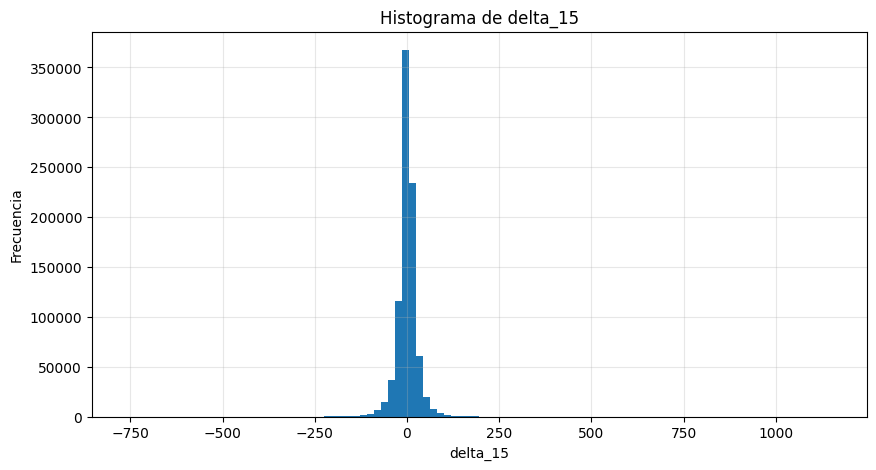

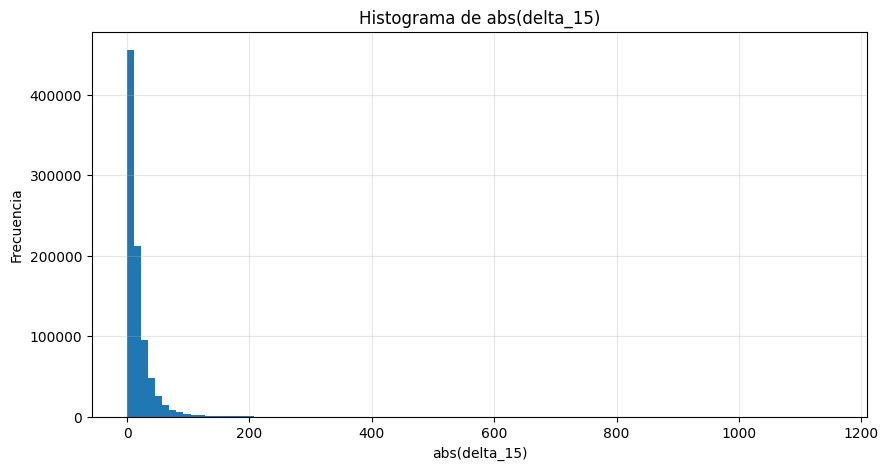

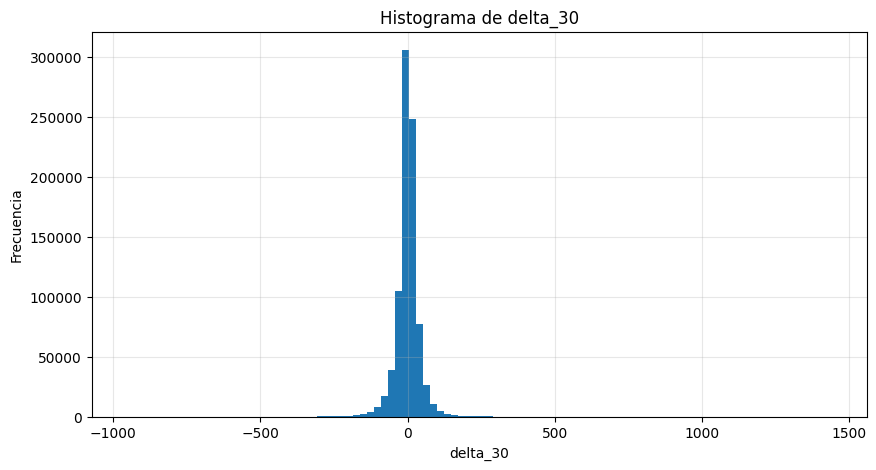

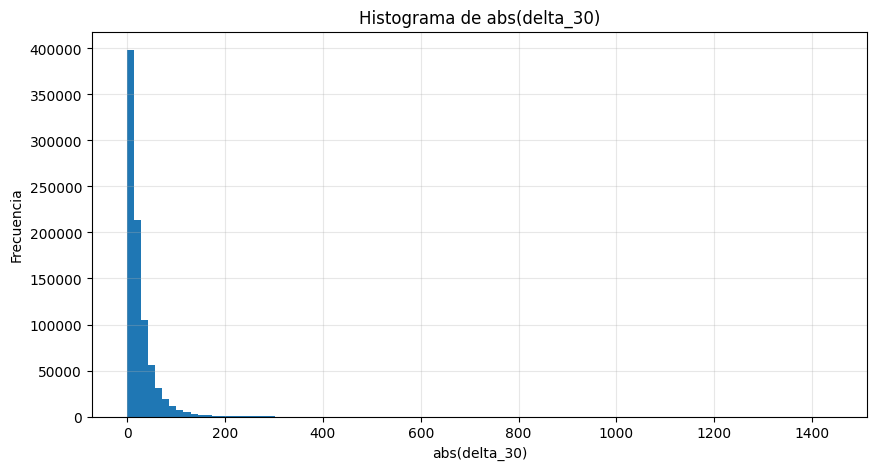

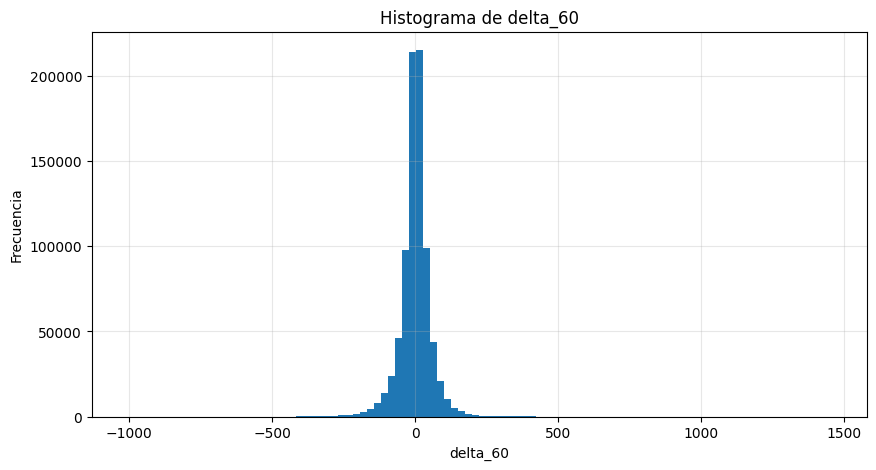

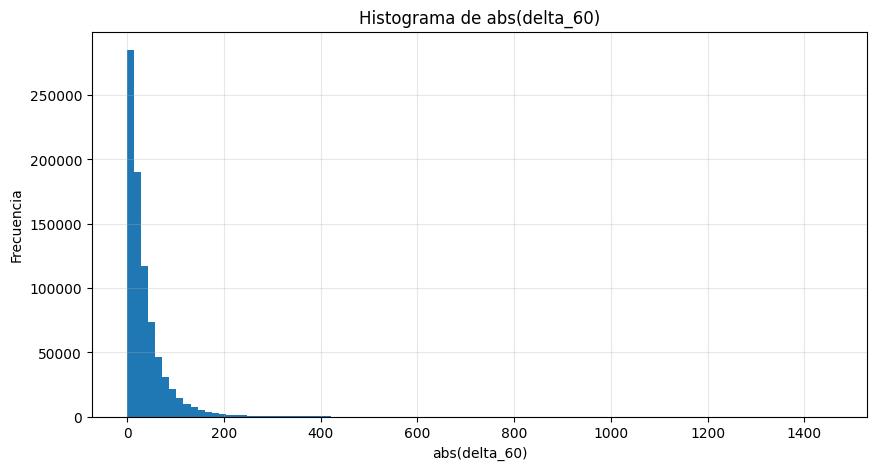

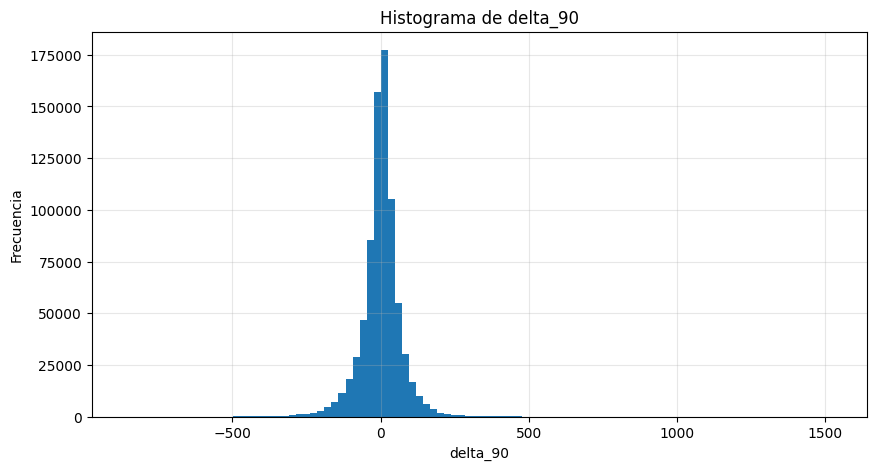

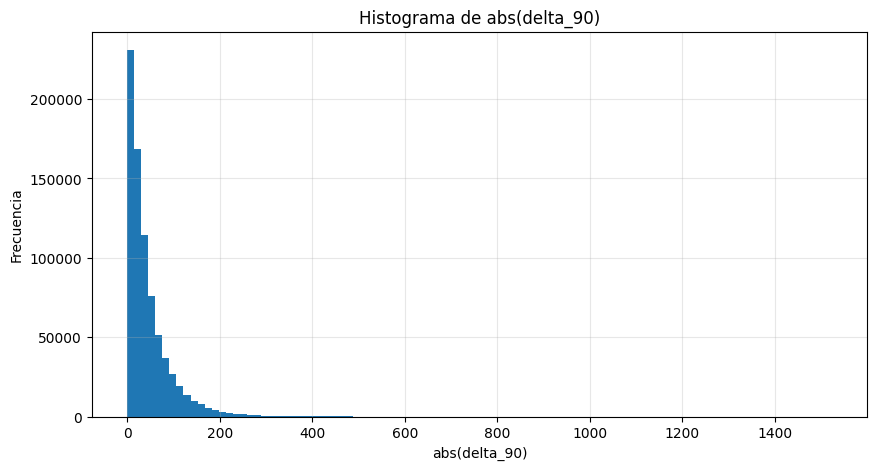

ANÁLISIS DE RUIDO VS SEÑAL
 h  n_obs  median_abs_delta  mean_abs_delta  prop_abs_le_5  prop_abs_le_10  prop_abs_le_20  prop_abs_ge_20  prop_abs_ge_40  prop_abs_ge_80  prop_direction_neg  prop_direction_zero  prop_direction_pos
15 875420             11.00       17.318192       0.268662        0.471402        0.717144        0.287168        0.099307        0.018259            0.478069             0.007003            0.514928
30 855995             15.75       24.866491       0.189633        0.351699        0.585690        0.418791        0.185193        0.048330            0.474472             0.004741            0.520787
60 817145             23.25       36.004706       0.133198        0.252687        0.450035        0.554284        0.305391        0.107865            0.468737             0.003334            0.527930
90 778295             29.25       44.971693       0.108288        0.207113        0.376199        0.627598        0.388840        0.163189            0.465065             0.

In [66]:
noise_signal = analyze_noise_vs_signal(
    mnq_targets,
    horizons=(15, 30, 60, 90),
    small_move_thresholds=(5, 10, 20),
    large_move_thresholds=(20, 40, 80),
    hist_bins=100,
    plot_histograms=True,
    use_clipped_for_hist=False,
    verbose=True,
)

### **Conclusiones del análisis de ruido vs señal**



El análisis muestra con claridad cómo se distribuye la magnitud del movimiento del precio y permite cuantificar qué proporción del target corresponde a ruido frente a movimientos potencialmente relevantes.

En primer lugar, en horizontes cortos (h=15), una gran parte de los movimientos son pequeños. Aproximadamente el 47% de los casos tienen |delta| ≤ 10 puntos y más del 70% están por debajo de 20 puntos. Esto indica que, en estos horizontes, el target está dominado por variaciones de baja magnitud, lo que sugiere una fuerte presencia de ruido.

A medida que aumenta el horizonte, la situación cambia de forma progresiva. En h=60 y h=90, la proporción de movimientos grandes crece significativamente:
- En h=60, más del 55% de los movimientos superan los 20 puntos.
- En h=90, este valor asciende a aproximadamente 63%.

Esto indica que en horizontes más largos el target contiene una mayor proporción de movimientos potencialmente explotables, reduciendo relativamente el peso del ruido.

La magnitud típica del movimiento también aumenta con el horizonte. La mediana de |delta| pasa de 11 puntos (h=15) a 29.25 puntos (h=90), lo cual confirma que los desplazamientos relevantes se vuelven más frecuentes a medida que se extiende el horizonte temporal.

Sin embargo, incluso en horizontes largos, sigue existiendo una fracción importante de movimientos pequeños, lo que implica que el problema continúa teniendo una componente significativa de ruido.

En cuanto a los movimientos extremos, la proporción de eventos grandes (por ejemplo |delta| ≥ 80) crece de manera notable:
- ~1.8% en h=15
- ~16.3% en h=90

Esto refuerza la idea de que la señal está concentrada en una minoría de eventos de alta magnitud, mientras que el resto del dataset está compuesto por movimientos más modestos.

Respecto a la dirección del movimiento, las clases se encuentran relativamente balanceadas en todos los horizontes. Existe un leve sesgo hacia movimientos positivos, que aumenta con el horizonte (de ~51.5% a ~53.2%), pero la distribución permanece cercana a 50/50. Esto implica que predecir dirección no es trivial y no existe una ventaja evidente por desbalance de clases.

En síntesis, el análisis permite concluir:

- En horizontes cortos, el target está fuertemente dominado por ruido (movimientos pequeños).
- A medida que aumenta el horizonte, crece la proporción de movimientos grandes y, por lo tanto, la señal potencial.
- La señal está concentrada en eventos relativamente poco frecuentes pero de mayor magnitud.
- La dirección del movimiento presenta un leve sesgo, pero sigue siendo esencialmente un problema balanceado.

Desde el punto de vista del modelado, estos resultados sugieren que horizontes más largos (como 60 o 90 minutos) podrían ser más favorables para capturar señal, aunque a costa de mayor variabilidad.

# **3. Estabilidad por régimen intradía (clave del proyecto)**

Dado que el problema es intradía, resulta fundamental analizar cómo se comporta el target en distintos momentos del mercado.

Este análisis permite identificar si la señal es homogénea a lo largo de la sesión o si, por el contrario, se concentra en ciertos regímenes específicos (apertura, sesión regular, cierre, etc.), lo cual es clave para entender dónde realmente existe oportunidad predictiva.

### **Código para estabilidad temporal**

In [68]:
import numpy as np
import pandas as pd


def analyze_intraday_regime_stability(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    include_base_targets: bool = True,
    include_derived_targets: bool = True,
    regime_cols: tuple[str, ...] = (
        "is_premarket",
        "is_opening",
        "is_regular",
        "is_closing",
        "is_overnight",
    ),
    percentiles: tuple[float, ...] = (0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99),
    verbose: bool = True,
) -> dict:
    """
    Analiza estabilidad por régimen intradía para todos los targets.

    Targets base:
    - delta_h
    - ret_h

    Targets derivados:
    - direction_h
    - abs_delta_h
    - delta_h_clipped
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas.DataFrame")

    if df.empty:
        raise ValueError("df está vacío")

    missing_regimes = [c for c in regime_cols if c not in df.columns]
    if missing_regimes:
        raise ValueError(f"Faltan columnas de régimen: {missing_regimes}")

    rows = []

    for h in horizons:
        target_cols = []

        if include_base_targets:
            target_cols.extend([
                f"delta_{h}",
                f"ret_{h}",
            ])

        if include_derived_targets:
            target_cols.extend([
                f"direction_{h}",
                f"abs_delta_{h}",
                f"delta_{h}_clipped",
            ])

        missing_targets = [c for c in target_cols if c not in df.columns]
        if missing_targets:
            raise ValueError(f"Faltan targets para h={h}: {missing_targets}")

        for regime_col in regime_cols:
            regime_mask = df[regime_col] == 1
            df_regime = df.loc[regime_mask].copy()

            for target in target_cols:
                s = df_regime[target]
                x = s.dropna()

                n_total = int(len(s))
                n_valid = int(len(x))
                n_nan = int(s.isna().sum())

                row = {
                    "regime": regime_col,
                    "h": h,
                    "target": target,
                    "n_total": n_total,
                    "n_valid": n_valid,
                    "n_nan": n_nan,
                }

                if n_valid == 0:
                    row.update({
                        "mean": np.nan,
                        "std": np.nan,
                        "min": np.nan,
                        "max": np.nan,
                        "skew": np.nan,
                        "kurtosis": np.nan,
                        "prop_zero": np.nan,
                        "prop_positive": np.nan,
                        "prop_negative": np.nan,
                    })
                    for p in percentiles:
                        row[f"p{int(p*100):02d}"] = np.nan
                else:
                    row.update({
                        "mean": float(x.mean()),
                        "std": float(x.std()),
                        "min": float(x.min()),
                        "max": float(x.max()),
                        "skew": float(x.skew()),
                        "kurtosis": float(x.kurtosis()),
                        "prop_zero": float((x == 0).mean()),
                        "prop_positive": float((x > 0).mean()),
                        "prop_negative": float((x < 0).mean()),
                    })

                    q = x.quantile(percentiles)
                    for p in percentiles:
                        row[f"p{int(p*100):02d}"] = float(q.loc[p])

                rows.append(row)

    summary_df = pd.DataFrame(rows)

    percentile_cols = [f"p{int(p*100):02d}" for p in percentiles]
    ordered_cols = [
        "regime", "h", "target",
        "n_total", "n_valid", "n_nan",
        "mean", "std", "min", *percentile_cols, "max",
        "skew", "kurtosis",
        "prop_zero", "prop_positive", "prop_negative",
    ]
    summary_df = summary_df[ordered_cols]

    # --------------------------------------------------
    # Resumen compacto por régimen y horizonte
    # --------------------------------------------------
    compact_df = (
        summary_df.groupby(["regime", "h"], as_index=False)
        .agg(
            n_targets=("target", "count"),
            avg_mean=("mean", "mean"),
            avg_std=("std", "mean"),
            avg_abs_mean=("mean", lambda s: float(np.nanmean(np.abs(s)))),
            avg_prop_positive=("prop_positive", "mean"),
            avg_prop_negative=("prop_negative", "mean"),
        )
    )

    # --------------------------------------------------
    # Tablas pivote útiles
    # --------------------------------------------------
    pivot_mean = summary_df.pivot_table(
        index=["regime", "target"],
        columns="h",
        values="mean"
    )

    pivot_std = summary_df.pivot_table(
        index=["regime", "target"],
        columns="h",
        values="std"
    )

    pivot_p50 = summary_df.pivot_table(
        index=["regime", "target"],
        columns="h",
        values="p50"
    )

    pivot_prop_positive = summary_df.pivot_table(
        index=["regime", "target"],
        columns="h",
        values="prop_positive"
    )

    if verbose:
        print("=" * 140)
        print("ESTABILIDAD POR RÉGIMEN INTRADÍA")
        print("=" * 140)

        print("\nResumen compacto por régimen y horizonte")
        print("-" * 140)
        print(compact_df.to_string(index=False))

        print("\nDetalle completo por régimen, horizonte y target")
        print("-" * 140)
        print(summary_df.to_string(index=False))

        print("\n" + "=" * 140)
        print("MEDIA POR RÉGIMEN / TARGET / HORIZONTE")
        print("=" * 140)
        print(pivot_mean.to_string())

        print("\n" + "=" * 140)
        print("STD POR RÉGIMEN / TARGET / HORIZONTE")
        print("=" * 140)
        print(pivot_std.to_string())

        print("\n" + "=" * 140)
        print("MEDIANA (P50) POR RÉGIMEN / TARGET / HORIZONTE")
        print("=" * 140)
        print(pivot_p50.to_string())

        print("\n" + "=" * 140)
        print("PROPORCIÓN DE POSITIVOS POR RÉGIMEN / TARGET / HORIZONTE")
        print("=" * 140)
        print(pivot_prop_positive.to_string())

        print("=" * 140)

    return {
        "summary": summary_df,
        "compact_summary": compact_df,
        "pivot_mean": pivot_mean,
        "pivot_std": pivot_std,
        "pivot_p50": pivot_p50,
        "pivot_prop_positive": pivot_prop_positive,
    }

In [69]:
regime_stability = analyze_intraday_regime_stability(
    mnq_targets,
    horizons=(15, 30, 60, 90),
    include_base_targets=True,
    include_derived_targets=True,
    regime_cols=(
        "is_premarket",
        "is_opening",
        "is_regular",
        "is_closing",
        "is_overnight",
    ),
    verbose=True,
)

ESTABILIDAD POR RÉGIMEN INTRADÍA

Resumen compacto por régimen y horizonte
--------------------------------------------------------------------------------------------------------------------------------------------
      regime  h  n_targets  avg_mean   avg_std  avg_abs_mean  avg_prop_positive  avg_prop_negative
  is_closing 15          5  4.378534 17.187561      4.603175           0.598552           0.395753
  is_closing 30          5  6.872630 25.809556      6.875410           0.595367           0.401544
  is_closing 60          5       NaN       NaN           NaN                NaN                NaN
  is_closing 90          5       NaN       NaN           NaN                NaN                NaN
  is_opening 15          5  6.455201 22.802623      6.455201           0.619233           0.377730
  is_opening 30          5  8.830070 31.001405      8.830070           0.623598           0.374291
  is_opening 60          5 11.506468 39.879843     11.528124           0.626224           0

In [71]:
print(regime_stability["summary"].to_string(index=False))

      regime  h           target  n_total  n_valid  n_nan          mean       std          min         p01         p05        p25       p50       p75        p95        p99         max      skew   kurtosis  prop_zero  prop_positive  prop_negative
is_premarket 15         delta_15    77700    77700      0 -7.874517e-02 27.687207  -451.000000  -84.002500  -42.000000 -11.250000  0.000000 11.250000  42.000000  82.000000  379.250000 -0.229135   9.782097   0.006396       0.499614       0.493990
is_premarket 15           ret_15    77700    77700      0  7.186828e-06  0.002026    -0.037689   -0.006042   -0.002959  -0.000775  0.000000  0.000780   0.003011   0.006031    0.034854 -0.287511  14.847399   0.006396       0.499614       0.493990
is_premarket 15     direction_15    77700    77700      0  5.624196e-03  0.996787    -1.000000   -1.000000   -1.000000  -1.000000  0.000000  1.000000   1.000000   1.000000    1.000000 -0.011249  -1.993487   0.006396       0.499614       0.493990
is_premarket 15 

### **Observaciones de la estabilidad por régimen intradía**

El análisis por régimen intradía muestra que la señal no es homogénea a lo largo de la sesión. Por el contrario, la distribución, la magnitud y el sesgo direccional de los targets cambian de forma clara según el momento del mercado.

La primera conclusión importante es que **apertura (`is_opening`) y sesión regular (`is_regular`) concentran la mayor magnitud de movimiento**, especialmente en horizontes de 60 y 90 minutos. Esto se observa tanto en `abs_delta_h` como en la dispersión de `delta_h` y `ret_h`. En particular, para `h=60` y `h=90`, la media y la mediana de `abs_delta_h` en apertura y regular son muy superiores a las observadas en overnight y, en general, también superiores a premarket. Esto sugiere que la mayor parte de la señal explotable está asociada a estos regímenes.

La **sesión regular** aparece como el régimen más prometedor para horizontes largos. Allí se observa:
- mayor media de `delta_h`,
- mayor mediana del movimiento,
- mayor proporción de movimientos positivos,
- y una magnitud típica claramente superior.

Por ejemplo, en `h=90`, `delta_90` en regular tiene media ≈ 1.66 puntos, mediana ≈ 4.75 y proporción de positivos ≈ 54.3%, lo que supera a los demás regímenes. Esto sugiere que, dentro del dataset, la señal direccional alcista y los movimientos relevantes están más presentes en la sesión regular.

La **apertura** también concentra movimientos grandes, pero con un comportamiento algo más inestable. En `h=15` y `h=30`, apertura ya muestra una magnitud elevada del movimiento. En `h=60` y `h=90`, sigue siendo un régimen fuerte en tamaño de desplazamiento, aunque la media de `delta_h` no siempre es tan favorable como en regular. Esto sugiere que apertura ofrece mucha actividad y volatilidad, pero no necesariamente una señal media tan estable como la sesión regular.

El **premarket** presenta una situación intermedia. A horizontes cortos su comportamiento es bastante neutral, con medias cercanas a cero y balance direccional casi simétrico. Sin embargo, en `h=60` y `h=90` la magnitud del movimiento crece y la proporción de positivos supera ligeramente a la de negativos. Esto indica que en premarket puede haber señal, pero en general parece más débil y menos consistente que en apertura o regular.

El régimen **overnight** muestra la menor magnitud de movimiento en casi todos los horizontes. Sus valores de `abs_delta_h`, así como sus medianas y desviaciones, son sistemáticamente menores que los de apertura y regular. Aunque presenta un leve sesgo positivo, la señal parece más débil y el movimiento típicamente más pequeño. En términos prácticos, overnight parece estar más dominado por ruido relativo que por desplazamientos amplios y explotables.

El régimen **closing** no es útil para horizontes de 60 y 90 minutos, porque directamente no dispone de observaciones válidas. Esto es lógico: no hay suficiente tramo intradía hacia adelante dentro de la jornada para construir targets tan largos. Incluso para `h=15` y `h=30`, closing queda con muy pocas observaciones válidas respecto al total, por lo que su utilidad para el modelado es limitada.

Otra conclusión importante es que la **dirección del movimiento también cambia por régimen**. En apertura y regular la proporción de positivos es mayor que en los demás regímenes, y esta diferencia se vuelve más clara en horizontes largos. En cambio, premarket y overnight tienden a estar más cerca del balance 50/50. Esto refuerza la idea de que, si existe señal direccional, no está distribuida uniformemente en la sesión sino concentrada sobre todo en apertura y regular.

En términos de forma de distribución, todos los regímenes siguen mostrando colas pesadas y presencia de outliers, pero la intensidad de este fenómeno es distinta. Apertura y regular no solo tienen mayor movimiento medio, sino también mayor dispersión y eventos extremos más relevantes. Esto es consistente con un régimen donde puede haber más señal, pero también mayor dificultad de modelado.

En síntesis, el análisis permite concluir lo siguiente:

- La señal intradía no es homogénea.
- **Apertura y sesión regular** concentran la mayor magnitud del movimiento y la mayor señal potencial.
- **La sesión regular** parece el régimen más estable y prometedor, especialmente para horizontes de 60 y 90 minutos.
- **Premarket** muestra señal más moderada.
- **Overnight** presenta menor magnitud y parece menos atractivo para el objetivo predictivo.
- **Closing** no es utilizable para horizontes largos y tiene valor muy limitado para horizontes cortos.

Desde el punto de vista del proyecto, esto sugiere que no conviene tratar toda la jornada como un único régimen homogéneo. La oportunidad predictiva parece estar concentrada principalmente en `is_opening` e `is_regular`, especialmente para `delta_60` y `delta_90`.

# **4. Dependencia temporal (predictabilidad base)**


En este punto se evalúa si los targets presentan memoria en el tiempo, es decir, si los valores pasados contienen información útil para predecir los futuros. Se analizan dos aspectos clave: la autocorrelación del target y la persistencia de la dirección del movimiento, lo que permite distinguir entre un proceso dominado por ruido y uno con potencial predictivo.

Este análisis es especialmente relevante porque permite confirmar si la señal observada previamente —particularmente en `is_opening` y `is_regular`— es realmente explotable o simplemente consecuencia de una mayor volatilidad.

Si la dependencia temporal se concentra en estos regímenes, se justifica incorporar el régimen en el modelado o incluso considerar modelos específicos por régimen. En cambio, si no se detecta dependencia temporal relevante, la señal observada debe interpretarse como ruido, independientemente del momento del día.

En síntesis, este punto determina si existe predictabilidad base y si dicha predictabilidad depende del régimen intradía.


4.1 Autocorrelación

- ACF del target  
- ACF de:
  - returns  
  - delta  

4.2 Persistencia direccional

- P(direction_t == direction_t-1)

## **4.1. Autocorrelación**

En este subpunto se analiza si los targets presentan dependencia lineal en el tiempo mediante la función de autocorrelación (ACF), lo que permite identificar memoria temporal en la serie.

Se evaluará:

- ACF del target  
- ACF de:  
  - returns  
  - delta  

**Nota sobre autocorrelación y solapamiento de ventanas:**

Al calcular la autocorrelación (ACF) de los targets como `delta_h` o `ret_h`, es importante tener en cuenta que estos están construidos utilizando ventanas temporales solapadas.

Por definición:
delta_h(t) = price(t+h) - price(t)

Si se calcula este target en cada instante, entonces:
- delta_h(t) utiliza datos desde t hasta t+h
- delta_h(t+1) utiliza datos desde t+1 hasta t+h+1

Ambos comparten la mayor parte de la ventana (h-1 observaciones), lo que induce una autocorrelación artificialmente alta, incluso en ausencia de señal real.

Como consecuencia, la ACF calculada directamente sobre estos targets no refleja dependencia temporal genuina, sino una propiedad mecánica derivada del solapamiento de ventanas.

Este efecto no implica un error en la construcción del dataset. De hecho, el solapamiento es necesario para el entrenamiento de modelos, ya que permite aprovechar toda la información disponible en alta frecuencia.

Sin embargo, para evaluar correctamente la dependencia temporal (y por lo tanto la posible predictabilidad), es necesario eliminar este efecto. La forma estándar de hacerlo es mediante subsampling, es decir, evaluando la ACF sobre observaciones separadas por el horizonte h, de modo que las ventanas no se solapen.

En resumen:
- El solapamiento es correcto y necesario para el modelado.
- Pero invalida el uso directo de la ACF.
- Para medir dependencia temporal real, se debe utilizar una versión no solapada del target.

### **Código de autocorrelación**

In [78]:
import numpy as np
import pandas as pd


def compute_acf(x: pd.Series, nlags: int = 20) -> np.ndarray:
    """
    Calcula ACF manualmente.
    """
    x = x.dropna().to_numpy()

    if len(x) == 0:
        return np.full(nlags + 1, np.nan)

    x = x - x.mean()
    denom = np.dot(x, x)

    if denom == 0:
        return np.full(nlags + 1, np.nan)

    acf_vals = []
    for lag in range(nlags + 1):
        if lag == 0:
            acf_vals.append(1.0)
        else:
            if len(x) <= lag:
                acf_vals.append(np.nan)
            else:
                num = np.dot(x[:-lag], x[lag:])
                acf_vals.append(num / denom)

    return np.array(acf_vals)


def classify_acf_strength(
    mean_abs_acf: float,
    mean_signed_acf: float,
    *,
    noise_thr: float = 0.03,
    signal_thr: float = 0.07,
) -> str:
    """
    Clasifica fuerza de dependencia temporal.
    """
    if np.isnan(mean_abs_acf) or np.isnan(mean_signed_acf):
        return "sin_datos"

    if mean_abs_acf < noise_thr:
        return "ruido"

    if mean_signed_acf < -noise_thr:
        if mean_abs_acf < signal_thr:
            return "reversión_débil"
        return "reversión"

    if mean_abs_acf < signal_thr:
        return "débil"

    return "señal"


def subsample_non_overlapping(series: pd.Series, step: int) -> pd.Series:
    """
    Subsamplea una serie cada `step` observaciones para evitar
    solapamiento entre ventanas de horizonte h.
    """
    x = series.dropna()
    return x.iloc[::step]


def analyze_acf_targets_non_overlapping(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    nlags: int = 20,
    regime_cols: tuple[str, ...] = (
        "is_premarket",
        "is_opening",
        "is_regular",
        "is_closing",
        "is_overnight",
    ),
    include_global: bool = True,
    noise_thr: float = 0.03,
    signal_thr: float = 0.07,
    verbose: bool = True,
):
    """
    Calcula ACF sobre targets subsampleados para evitar solapamiento.

    Targets:
    - delta_h
    - ret_h
    - direction_h

    Scope:
    - global
    - por régimen intradía
    """

    missing_regimes = [c for c in regime_cols if c not in df.columns]
    if missing_regimes:
        raise ValueError(f"Faltan columnas de régimen: {missing_regimes}")

    rows = []

    scopes = []
    if include_global:
        scopes.append(("global", pd.Series(True, index=df.index)))

    for regime in regime_cols:
        scopes.append((regime, df[regime] == 1))

    for scope_name, scope_mask in scopes:
        df_scope = df.loc[scope_mask].copy()

        for h in horizons:
            targets = [
                f"delta_{h}",
                f"ret_{h}",
                f"direction_{h}",
            ]

            for col in targets:
                if col not in df_scope.columns:
                    continue

                s_raw = df_scope[col]
                s = subsample_non_overlapping(s_raw, step=h)
                n_obs = len(s)

                if n_obs <= nlags + 1:
                    row = {
                        "scope": scope_name,
                        "target": col,
                        "h": h,
                        "n_obs": n_obs,
                    }
                    for lag in range(1, min(6, nlags + 1)):
                        row[f"acf_lag_{lag}"] = np.nan
                    row["acf_mean_lag1_5"] = np.nan
                    row["acf_mean_abs_lag1_5"] = np.nan
                    row["acf_max_abs_lag1_5"] = np.nan
                    row["classification"] = "sin_datos"
                    rows.append(row)
                    continue

                acf_vals = compute_acf(s, nlags=nlags)

                lag_window = acf_vals[1:6]
                mean_signed = float(np.nanmean(lag_window))
                mean_abs = float(np.nanmean(np.abs(lag_window)))
                max_abs = float(np.nanmax(np.abs(lag_window)))

                classification = classify_acf_strength(
                    mean_abs,
                    mean_signed,
                    noise_thr=noise_thr,
                    signal_thr=signal_thr,
                )

                row = {
                    "scope": scope_name,
                    "target": col,
                    "h": h,
                    "n_obs": n_obs,
                    "acf_mean_lag1_5": mean_signed,
                    "acf_mean_abs_lag1_5": mean_abs,
                    "acf_max_abs_lag1_5": max_abs,
                    "classification": classification,
                }

                for lag in range(1, min(6, nlags + 1)):
                    row[f"acf_lag_{lag}"] = float(acf_vals[lag])

                rows.append(row)

    acf_df = pd.DataFrame(rows)

    compact_df = (
        acf_df.groupby(["scope", "h"], as_index=False)
        .agg(
            n_targets=("target", "count"),
            avg_acf_lag1=("acf_lag_1", "mean"),
            avg_acf_lag2=("acf_lag_2", "mean"),
            avg_mean_abs_lag1_5=("acf_mean_abs_lag1_5", "mean"),
        )
    )

    class_df = acf_df[[
        "scope", "h", "target", "n_obs",
        "acf_lag_1", "acf_lag_2", "acf_lag_3", "acf_lag_4", "acf_lag_5",
        "acf_mean_lag1_5", "acf_mean_abs_lag1_5", "acf_max_abs_lag1_5",
        "classification"
    ]].copy()

    if verbose:
        print("=" * 130)
        print("AUTOCORRELACIÓN (ACF) DE TARGETS - NO SOLAPADA")
        print("=" * 130)

        print("\nReglas de clasificación")
        print("-" * 130)
        print(f"|ACF| < {noise_thr:.2f}               -> ruido")
        print(f"{noise_thr:.2f} <= |ACF| < {signal_thr:.2f}      -> débil")
        print(f"|ACF| >= {signal_thr:.2f}            -> señal")
        print("Media ACF negativa y relevante       -> reversión / reversión_débil")

        print("\nResumen por scope y horizonte")
        print("-" * 130)
        print(compact_df.to_string(index=False))

        print("\nClasificación por target")
        print("-" * 130)
        print(class_df.to_string(index=False))

        print("=" * 130)

    return {
        "acf_detail": acf_df,
        "acf_summary": compact_df,
        "acf_classification": class_df,
    }

In [79]:
acf_results = analyze_acf_targets_non_overlapping(
    mnq_targets,
    horizons=(15, 30, 60, 90),
    nlags=20,
    regime_cols=(
        "is_premarket",
        "is_opening",
        "is_regular",
        "is_closing",
        "is_overnight",
    ),
    include_global=True,
    noise_thr=0.03,
    signal_thr=0.07,
    verbose=True,
)

AUTOCORRELACIÓN (ACF) DE TARGETS - NO SOLAPADA

Reglas de clasificación
----------------------------------------------------------------------------------------------------------------------------------
|ACF| < 0.03               -> ruido
0.03 <= |ACF| < 0.07      -> débil
|ACF| >= 0.07            -> señal
Media ACF negativa y relevante       -> reversión / reversión_débil

Resumen por scope y horizonte
----------------------------------------------------------------------------------------------------------------------------------
       scope  h  n_targets  avg_acf_lag1  avg_acf_lag2  avg_mean_abs_lag1_5
      global 15          3      0.005780     -0.009194             0.008099
      global 30          3     -0.005527     -0.002589             0.004369
      global 60          3     -0.004938      0.009059             0.009785
      global 90          3      0.012877      0.008776             0.015096
  is_closing 15          3     -0.070965      0.041562             0.047034
  is_c

### **Conclusiones de autocorrelación**

El análisis de autocorrelación (ACF), realizado sobre los targets sin solapamiento entre ventanas, muestra de forma consistente que la serie se comporta como un proceso cercano al ruido.

A nivel global, todos los targets (delta, ret y direction) presentan valores de ACF muy cercanos a cero en los primeros lags. Esto indica que los valores pasados no contienen información útil para predecir los futuros, es decir, no existe memoria temporal explotable.

Al analizar por régimen intradía, los resultados se mantienen en la misma línea. En los periodos más relevantes para la operativa —is_opening y is_regular— la autocorrelación sigue siendo prácticamente nula en todos los horizontes (15, 30, 60 y 90 minutos). Esto implica que, aunque en estos periodos exista mayor actividad o volatilidad, dicha dinámica no se traduce en mayor predictabilidad.

En los regímenes de premarket y overnight aparecen algunos indicios de autocorrelación débil, pero son inconsistentes y de baja magnitud, por lo que no constituyen una señal robusta.

El único caso donde se observan valores de ACF más elevados es en el régimen de closing, incluso con indicios de reversión. Sin embargo, este resultado no es confiable debido al bajo número de observaciones disponibles, por lo que no puede considerarse evidencia sólida.

En conjunto, los resultados indican que los targets no presentan dependencia temporal significativa. La dinámica observada en el mercado está dominada por ruido desde el punto de vista de la autocorrelación.

Como consecuencia, no existe evidencia que justifique el uso de modelos basados en memoria temporal (como LSTM o Transformers) para explotar dependencias del propio target. En cambio, el desempeño de los modelos dependerá principalmente de la información contenida en las variables explicativas (features) y no de la historia del target en sí.

---

**El análisis de autocorrelación no indica que el problema carezca de señal, sino que dicha señal no está contenida en la historia del propio target. En otras palabras, los valores pasados del target no aportan información útil para predecir sus valores futuros. Esta conclusión es clave, ya que orienta el diseño del modelo hacia el uso de variables explicativas (features) y no hacia la explotación de dependencias temporales del target.**

## **4.2 Persistencia direccional**


El análisis de persistencia direccional evalúa si la dirección del movimiento del mercado tiende a repetirse en el tiempo. En particular, se mide la probabilidad de que la dirección en un instante $ 𝑡 $ sea igual a la dirección en $𝑡 − 1$, es decir, $𝑃(direction_{t} = direction_{t-1})$.

Este análisis es complementario a la autocorrelación. Mientras que la ACF mide dependencia en magnitud, la persistencia direccional se enfoca únicamente en el signo del movimiento (sube o baja), lo que puede revelar patrones que no son visibles en la ACF.

Su utilidad principal es determinar si existe algún grado de continuidad o reversión en la dirección del mercado. Si esta probabilidad es cercana a 0.5, el proceso es esencialmente aleatorio. Si es mayor a 0.5, sugiere persistencia (tendencia), mientras que valores menores a 0.5 indican reversión.

Este análisis permite identificar si existe señal explotable desde el punto de vista direccional, incluso en escenarios donde la autocorrelación es baja, y ayuda a validar si estrategias basadas en tendencia o reversión podrían tener fundamento estadístico.

### **Código de persistencia direccional**

In [80]:
import numpy as np
import pandas as pd


def subsample_non_overlapping(series: pd.Series, step: int) -> pd.Series:
    """
    Subsamplea una serie cada `step` observaciones para evitar
    solapamiento entre ventanas de horizonte h.
    """
    x = series.dropna()
    return x.iloc[::step]


def classify_direction_persistence(
    p_same: float,
    *,
    neutral_low: float = 0.47,
    neutral_high: float = 0.53,
    strong_persistence: float = 0.57,
    strong_reversal: float = 0.43,
) -> str:
    """
    Clasifica la persistencia direccional.
    """
    if np.isnan(p_same):
        return "sin_datos"

    if p_same >= strong_persistence:
        return "persistencia"

    if p_same > neutral_high:
        return "persistencia_débil"

    if p_same <= strong_reversal:
        return "reversión"

    if p_same < neutral_low:
        return "reversión_débil"

    return "neutral"


def analyze_directional_persistence(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (15, 30, 60, 90),
    regime_cols: tuple[str, ...] = (
        "is_premarkat",
        "is_opening",
        "is_regular",
        "is_closing",
        "is_overnight",
    ),
    include_global: bool = True,
    neutral_low: float = 0.47,
    neutral_high: float = 0.53,
    strong_persistence: float = 0.57,
    strong_reversal: float = 0.43,
    verbose: bool = True,
):
    """
    Calcula persistencia direccional no solapada:

    P(direction_t == direction_{t-1})

    para:
    - global
    - por régimen intradía

    Usa direction_h y subsampling cada h pasos.
    """

    # corregir typo común por robustez
    regime_cols = tuple("is_premarket" if c == "is_premarkat" else c for c in regime_cols)

    missing_regimes = [c for c in regime_cols if c not in df.columns]
    if missing_regimes:
        raise ValueError(f"Faltan columnas de régimen: {missing_regimes}")

    rows = []

    scopes = []
    if include_global:
        scopes.append(("global", pd.Series(True, index=df.index)))

    for regime in regime_cols:
        scopes.append((regime, df[regime] == 1))

    for scope_name, scope_mask in scopes:
        df_scope = df.loc[scope_mask].copy()

        for h in horizons:
            col = f"direction_{h}"
            if col not in df_scope.columns:
                raise ValueError(f"Falta la columna requerida: '{col}'")

            s_raw = df_scope[col]
            s = subsample_non_overlapping(s_raw, step=h)

            # quitar ceros para evaluar solo cambios direccionales efectivos
            s = s[s != 0]

            n_obs = len(s)

            if n_obs < 2:
                rows.append({
                    "scope": scope_name,
                    "h": h,
                    "target": col,
                    "n_obs": n_obs,
                    "n_pairs": 0,
                    "p_same": np.nan,
                    "p_change": np.nan,
                    "p_pos_to_pos": np.nan,
                    "p_neg_to_neg": np.nan,
                    "classification": "sin_datos",
                })
                continue

            prev = s.shift(1)
            curr = s

            valid = prev.notna() & curr.notna()
            prev = prev[valid]
            curr = curr[valid]

            n_pairs = len(curr)

            same = (curr == prev)
            change = (curr != prev)

            pos_to_pos_mask = prev == 1
            neg_to_neg_mask = prev == -1

            p_same = float(same.mean()) if n_pairs > 0 else np.nan
            p_change = float(change.mean()) if n_pairs > 0 else np.nan

            p_pos_to_pos = (
                float((curr[pos_to_pos_mask] == 1).mean())
                if pos_to_pos_mask.sum() > 0 else np.nan
            )
            p_neg_to_neg = (
                float((curr[neg_to_neg_mask] == -1).mean())
                if neg_to_neg_mask.sum() > 0 else np.nan
            )

            classification = classify_direction_persistence(
                p_same,
                neutral_low=neutral_low,
                neutral_high=neutral_high,
                strong_persistence=strong_persistence,
                strong_reversal=strong_reversal,
            )

            rows.append({
                "scope": scope_name,
                "h": h,
                "target": col,
                "n_obs": n_obs,
                "n_pairs": n_pairs,
                "p_same": p_same,
                "p_change": p_change,
                "p_pos_to_pos": p_pos_to_pos,
                "p_neg_to_neg": p_neg_to_neg,
                "classification": classification,
            })

    detail_df = pd.DataFrame(rows)

    compact_df = (
        detail_df.groupby(["scope", "h"], as_index=False)
        .agg(
            n_targets=("target", "count"),
            avg_p_same=("p_same", "mean"),
            avg_p_change=("p_change", "mean"),
        )
    )

    if verbose:
        print("=" * 120)
        print("PERSISTENCIA DIRECCIONAL - NO SOLAPADA")
        print("=" * 120)

        print("\nReglas de clasificación")
        print("-" * 120)
        print(f"p_same < {strong_reversal:.2f}             -> reversión")
        print(f"{strong_reversal:.2f} <= p_same < {neutral_low:.2f} -> reversión_débil")
        print(f"{neutral_low:.2f} <= p_same <= {neutral_high:.2f} -> neutral")
        print(f"{neutral_high:.2f} < p_same < {strong_persistence:.2f} -> persistencia_débil")
        print(f"p_same >= {strong_persistence:.2f}         -> persistencia")

        print("\nResumen por scope y horizonte")
        print("-" * 120)
        print(compact_df.to_string(index=False))

        print("\nDetalle por target")
        print("-" * 120)
        print(detail_df.to_string(index=False))

        print("=" * 120)

    return {
        "detail": detail_df,
        "summary": compact_df,
    }

In [81]:
direction_persistence = analyze_directional_persistence(
    mnq_targets,
    horizons=(15, 30, 60, 90),
    regime_cols=(
        "is_premarket",
        "is_opening",
        "is_regular",
        "is_closing",
        "is_overnight",
    ),
    include_global=True,
    verbose=True,
)

PERSISTENCIA DIRECCIONAL - NO SOLAPADA

Reglas de clasificación
------------------------------------------------------------------------------------------------------------------------
p_same < 0.43             -> reversión
0.43 <= p_same < 0.47 -> reversión_débil
0.47 <= p_same <= 0.53 -> neutral
0.53 < p_same < 0.57 -> persistencia_débil
p_same >= 0.57         -> persistencia

Resumen por scope y horizonte
------------------------------------------------------------------------------------------------------------------------
       scope  h  n_targets  avg_p_same  avg_p_change
      global 15          1    0.500639      0.499361
      global 30          1    0.499859      0.500141
      global 60          1    0.499889      0.500111
      global 90          1    0.500754      0.499246
  is_closing 15          1    0.500364      0.499636
  is_closing 30          1    0.511628      0.488372
  is_closing 60          1         NaN           NaN
  is_closing 90          1         NaN     

### **Observaciones de persistencia direccional**

El análisis de persistencia direccional muestra de forma consistente que la dirección del mercado no presenta patrones de continuidad ni de reversión explotables.

A nivel global, la probabilidad de que la dirección se repita entre pasos consecutivos se mantiene prácticamente en 0.5 para todos los horizontes (15, 30, 60 y 90 minutos). Esto indica que el movimiento del mercado es direccionalmente aleatorio, sin evidencia de tendencia ni reversión en el corto plazo.

Al analizar por régimen intradía, los resultados se mantienen estables. En los periodos más relevantes para la operativa —is_opening y is_regular— los valores de persistencia se encuentran dentro del rango neutral, con ligeras desviaciones que no son estadísticamente significativas. Esto implica que, aunque exista mayor actividad en estos periodos, no hay continuidad direccional aprovechable.

En los regímenes de premarket y overnight se observan pequeñas variaciones alrededor de 0.5, pero sin consistencia ni magnitud suficiente como para considerarlas señal real. En el caso de closing, los resultados son igualmente neutrales y además limitados por un bajo número de observaciones.

En conjunto, este análisis confirma que la dirección del movimiento del mercado se comporta de manera aleatoria en los horizontes evaluados. No existe evidencia de persistencia direccional ni de reversión sistemática.

Como consecuencia, no es posible construir estrategias basadas únicamente en la repetición de la dirección del movimiento. Al igual que en el análisis de autocorrelación, cualquier capacidad predictiva deberá provenir de las variables explicativas (features) y no de la historia del target.

# **CONTINÚA CON EL PUNTO 5**